## paperfigs_rev01
Generate figures for paper (revision 01):


In [19]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from pathlib import Path
import pandas as pd

import sys
sys.path.insert(0, '/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/src')
from utils import geosoft_cmap_k65
geosoft_cmap = geosoft_cmap_k65()


## Figure 3

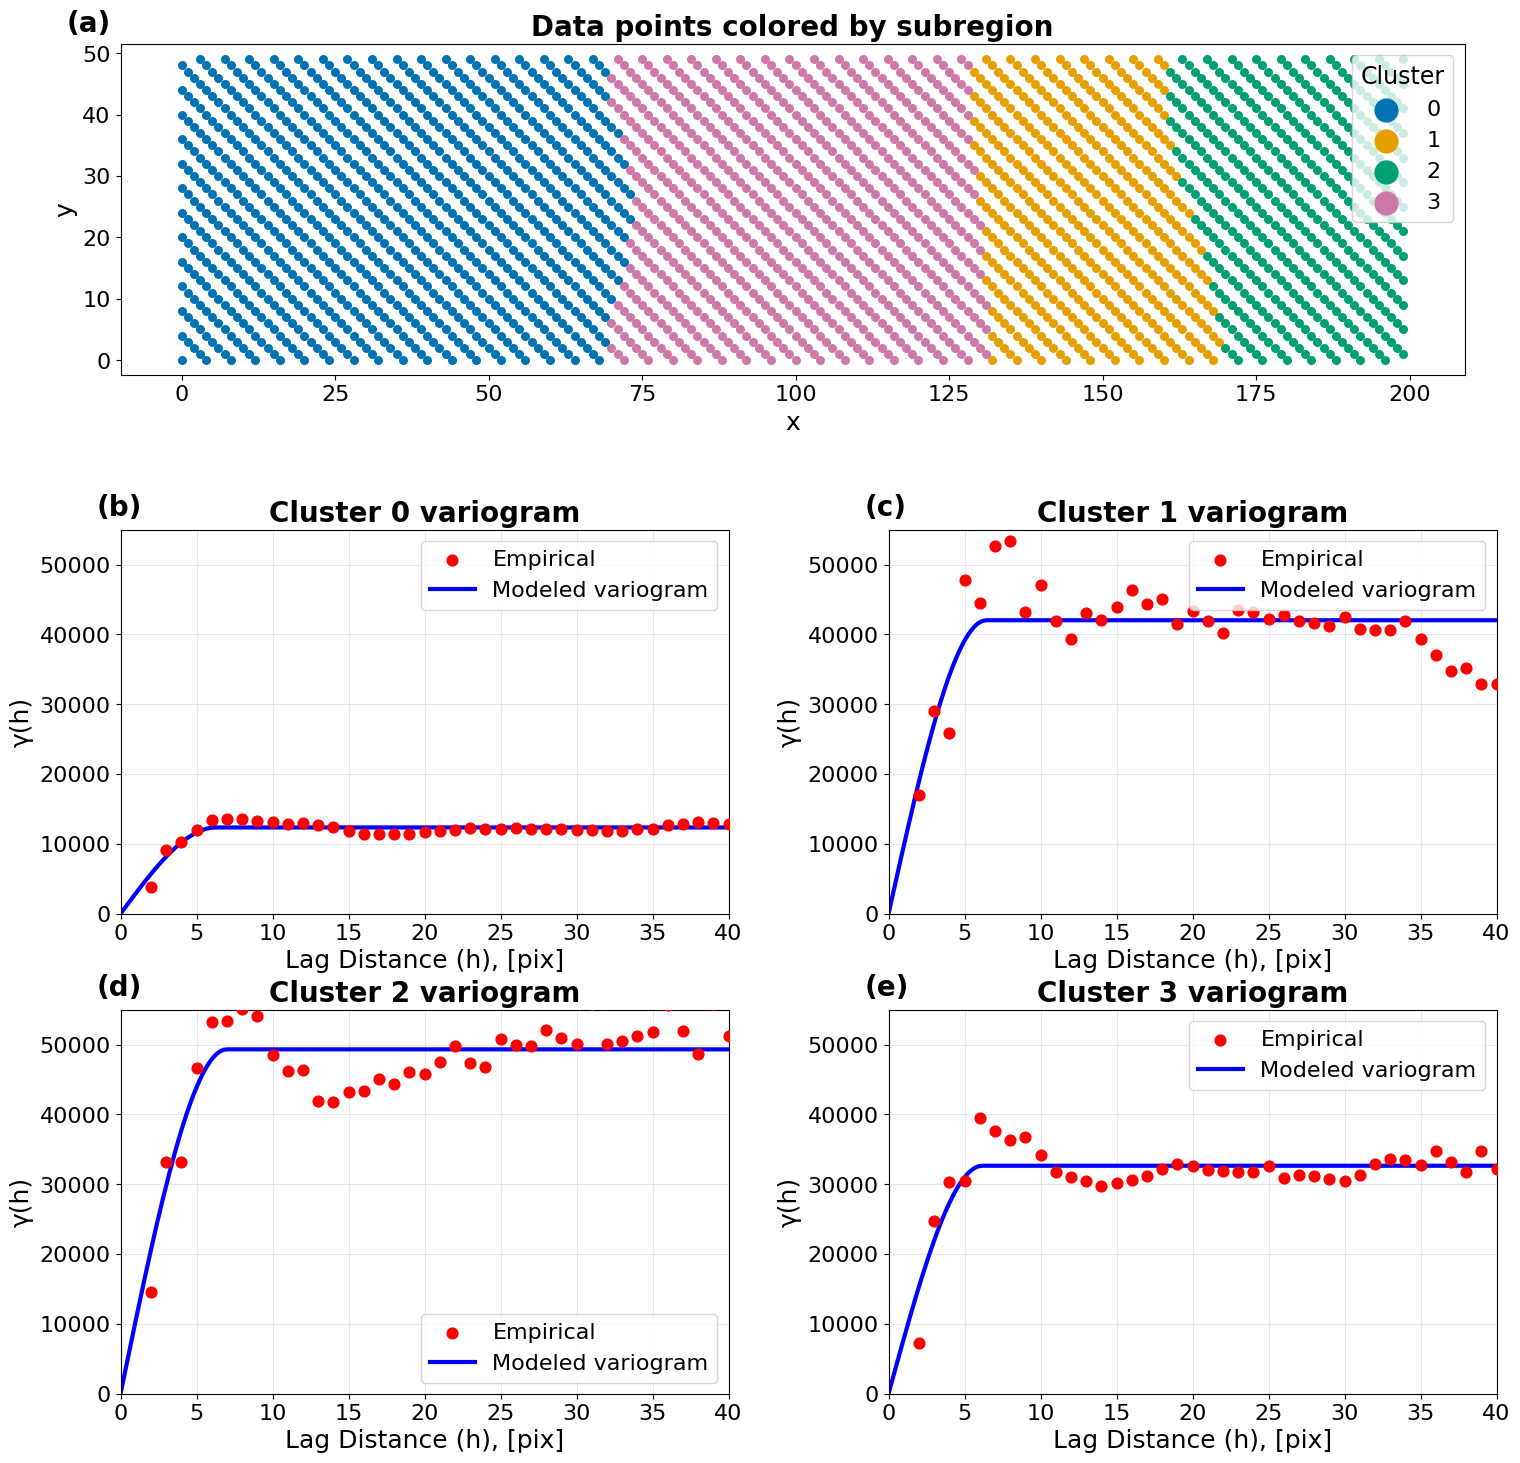


Fitted spherical variogram parameters:
Cluster    Range        Sill         Nugget      
----------------------------------------------
0          6.30         12356.6      0.0000      
1          6.44         42036.1      0.0000      
2          6.99         49324.5      0.0000      
3          6.17         32652.7      0.0000      


In [24]:
## FIGURE: Data points + cluster variograms (spherical) ##
## ==================================================== ##

import sys
sys.path.insert(0, '/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/src')
from variograms import cluster_variogram
import json

# --- Load flight line data ---
fl_path = '/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/demos/data/fl_xyvc_dense.csv'
df_fl = pd.read_csv(fl_path)
df_fl.columns = ['x', 'y', 'value', 'cluster']
df_fl['cluster'] = df_fl['cluster'].astype(int)

# --- Load config data (for trend / residuals) ---
cfg_data = pd.read_csv('/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/configs/config_iso_subregions_dense_data.csv')
obs = cfg_data[cfg_data['set'] == 1].copy()
df_fl = df_fl.merge(obs[['x', 'y', 'residual']], on=['x', 'y'], how='left')

# --- Variogram parameters ---
maxlag = 40
n_lags = 40
model = 'spherical'
n_clusters = df_fl['cluster'].nunique()

variograms = []
for i in range(n_clusters):
    V = cluster_variogram(df_fl, 'residual', i, maxlag, n_lags, model)
    variograms.append(V)

# --- Colorblind-safe palette (Wong 2011) ---
cluster_colors = {
    0: '#0072B2',  # blue
    1: '#E69F00',  # orange
    2: '#009E73',  # green
    3: '#CC79A7',  # pink
}

# --- Build figure ---
fig = plt.figure(figsize=(16, 16))

# (a) Data points colored by subregion
ax_a = fig.add_axes([0.08, 0.64, 0.84, 0.28])
for ci in range(n_clusters):
    mask = df_fl['cluster'] == ci
    ax_a.scatter(df_fl.loc[mask, 'x'], df_fl.loc[mask, 'y'],
                 c=cluster_colors[ci], s=30, label=f'{ci}', rasterized=True)
ax_a.set_xlabel('x', fontsize=18)
ax_a.set_ylabel('y', fontsize=18)
ax_a.set_title('Data points colored by subregion', fontsize=20, fontweight='bold')
ax_a.set_aspect('equal')
ax_a.legend(title='Cluster', markerscale=3, fontsize=16, title_fontsize=17)
ax_a.tick_params(labelsize=16)
ax_a.text(-0.04, 1.02, '(a)', transform=ax_a.transAxes, fontsize=20, fontweight='bold', va='bottom')

# (b-e) Cluster variograms
panel_labels = ['(b)', '(c)', '(d)', '(e)']
positions = [
    [0.08, 0.34, 0.38, 0.24],
    [0.56, 0.34, 0.38, 0.24],
    [0.08, 0.04, 0.38, 0.24],
    [0.56, 0.04, 0.38, 0.24],
]

for i, V in enumerate(variograms):
    ax = fig.add_axes(positions[i])

    # Empirical variogram points
    ax.scatter(V.bins, V.experimental, c='red', s=60, zorder=3, label='Empirical')

    # Fitted model curve
    h = np.linspace(0, V.bins[-1], 200)
    gamma_model = V.transform(h)
    ax.plot(h, gamma_model, color='blue', linewidth=3, label='Modeled variogram')

    r, s, n = V.parameters
    ax.set_xlabel('Lag Distance (h), [pix]', fontsize=18)
    ax.set_ylabel('γ(h)', fontsize=18)
    ax.set_title(f'Cluster {i} variogram', fontsize=20, fontweight='bold')
    ax.set_xlim(0, maxlag)
    ax.set_ylim(0, 55000)
    ax.legend(fontsize=16)
    ax.tick_params(labelsize=16)
    ax.grid(True, alpha=0.3)
    ax.text(-0.04, 1.02, panel_labels[i], transform=ax.transAxes,
            fontsize=20, fontweight='bold', va='bottom')

plt.show()

# Print fitted parameters
print("\nFitted spherical variogram parameters:")
print(f"{'Cluster':<10} {'Range':<12} {'Sill':<12} {'Nugget':<12}")
print("-" * 46)
for i, V in enumerate(variograms):
    r, s, n = V.parameters
    print(f"{i:<10} {r:<12.2f} {s:<12.1f} {n:<12.4f}")


## Figure 4

In [32]:
## --- Run MGSIM loop, capturing intermediates ---
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

sys.path.insert(0, '/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/src')
import gstatsim as gs
from sampling import subsample_dataframe
from utils import geosoft_cmap_k65

geosoft_cmap = geosoft_cmap_k65()

# --- Load config ---
cfg_dir = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/configs')
with open(cfg_dir / 'config_sph_iso_subregions_dense.json') as f:
    config = json.load(f)

df_xyvtcs = pd.read_csv(cfg_dir / config['data_file'])
df_gamma = pd.DataFrame({'Variogram': config['variograms_list']})
mg_resols = config['mg_resols']
grid_shape = tuple(config['grid_shape'])  # (50, 200)
rows, cols = grid_shape
kw = config['mgsim_kwargs']
xx, yy, zz, kk = kw['xx'], kw['yy'], kw['zz'], kw['kk']
num_points, radius = kw['num_points'], kw['radius']

# --- Run MGSIM loop, capturing intermediates ---
np.random.seed(42)

df_all = df_xyvtcs.copy()
sim_mask = df_all[kk] >= 0
df = df_all.loc[sim_mask].copy()
pred_xy_grid = df[['x', 'y']].values
df['residual'] = df['value'] - df['trend']
df['newtrend'] = df['trend'].copy()

snapshots = []

for i, mg_resol in enumerate(mg_resols):
    print(f"Iteration {i+1}/{len(mg_resols)}: resolution={mg_resol}")

    df_obspts = df[df['set'] == 1].copy()
    if i < len(mg_resols) - 1:
        df_mgsmpl = subsample_dataframe(df_obspts, column_for_sampling='residual', spacing=mg_resol)
    else:
        df_mgsmpl = df_obspts.copy()

    mgsgs = gs.Interpolation.cluster_sgs(
        pred_xy_grid, df_mgsmpl, xx, yy, zz, kk, num_points, df_gamma, radius
    )

    df['newtrend'] = df['newtrend'] + mgsgs
    df['residual'] = df['value'] - df['newtrend']

    # Capture snapshot
    newtrend_grid = np.full(rows * cols, np.nan)
    newtrend_grid[sim_mask.values] = df['newtrend'].values
    newtrend_grid = newtrend_grid.reshape(rows, cols)

    snapshots.append({
        'iter': i + 1,
        'mg_resol': mg_resol,
        'df_mgsmpl': df_mgsmpl.copy(),
        'obs_residuals': df.loc[df['set'] == 1, 'residual'].values.copy(),
        'newtrend_grid': newtrend_grid,
        'n_subsampled': len(df_mgsmpl),
    })

print(f"\nDone! Captured {len(snapshots)} snapshots.")

Iteration 1/8: resolution=20


100%|██████████| 10000/10000 [00:28<00:00, 348.57it/s]


Iteration 2/8: resolution=15


100%|██████████| 10000/10000 [00:28<00:00, 345.60it/s]


Iteration 3/8: resolution=10


...

Iteration 7/8: resolution=2


100%|██████████| 10000/10000 [00:23<00:00, 433.86it/s]


Iteration 8/8: resolution=1


100%|██████████| 10000/10000 [00:23<00:00, 426.31it/s]


Done! Captured 8 snapshots.


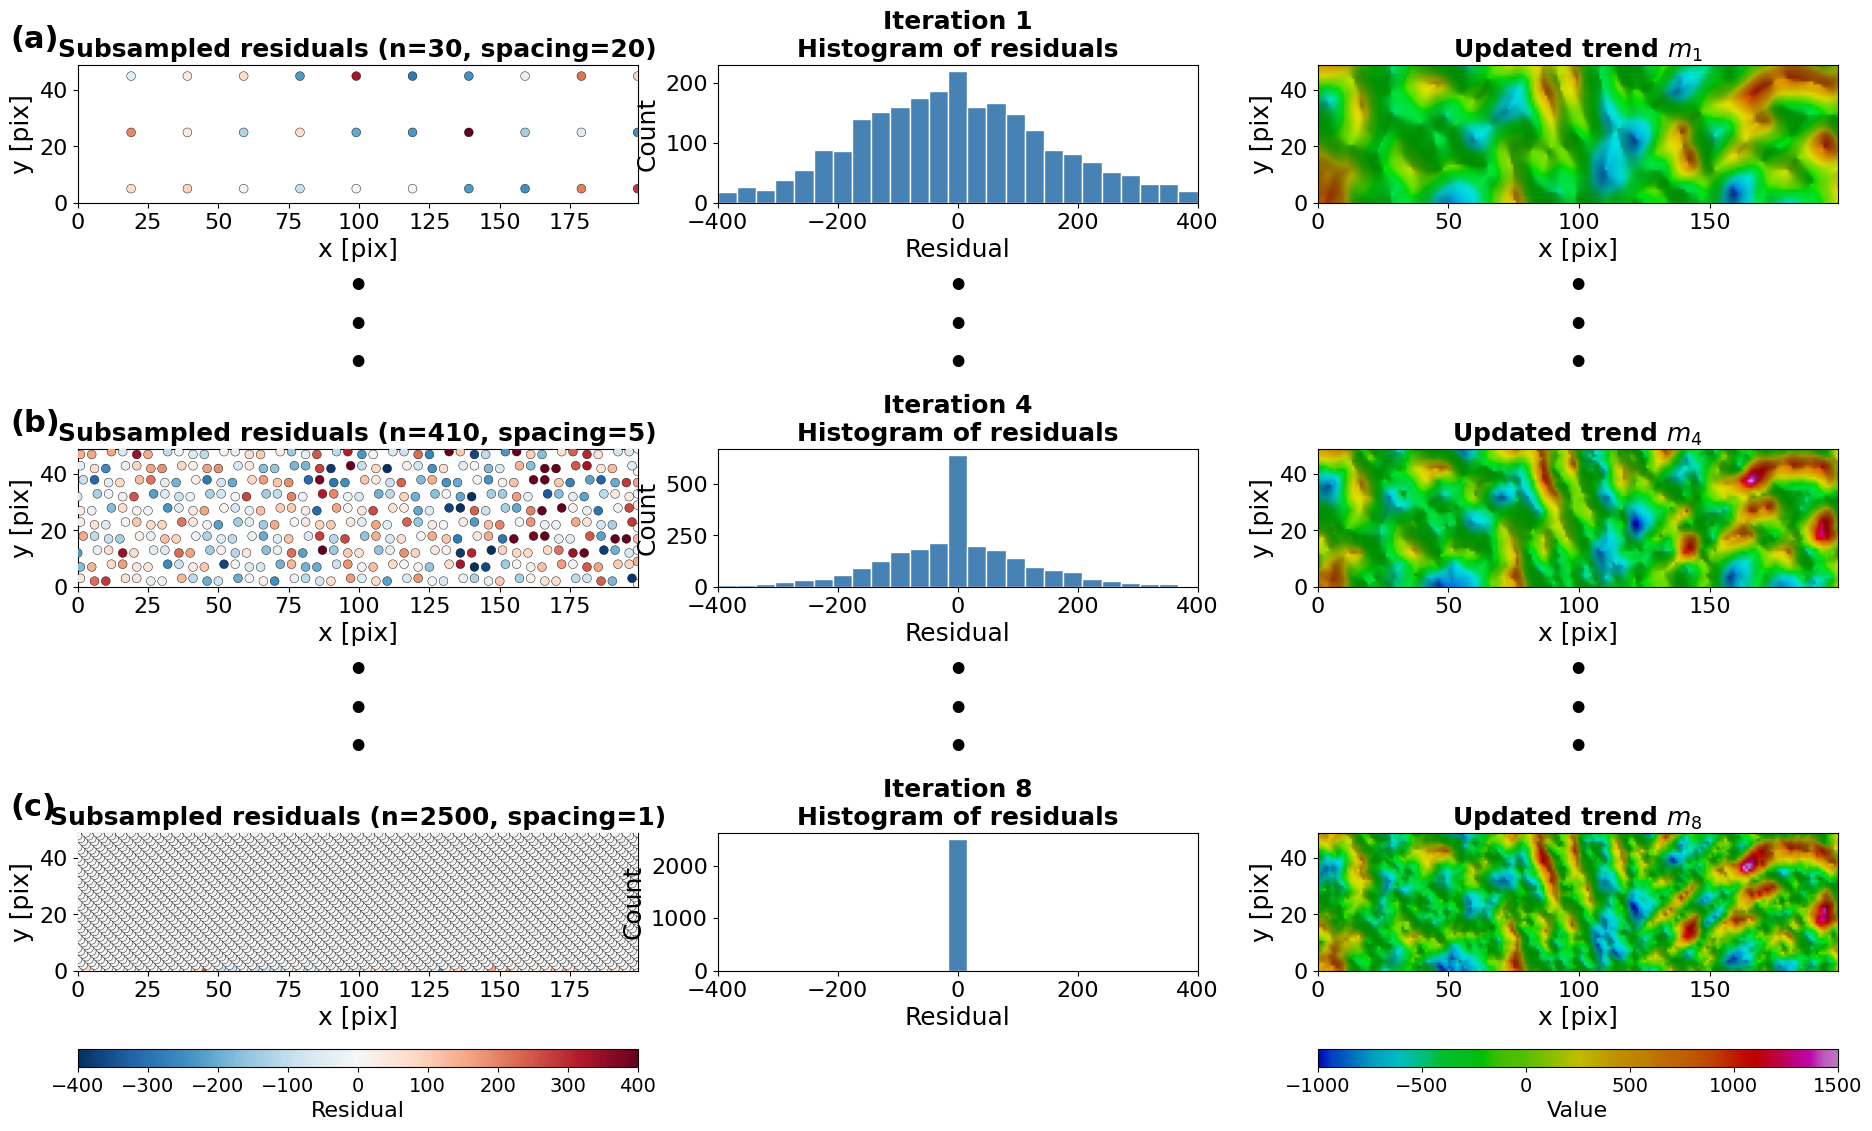

In [38]:
## FIGURE: MGSIM Iteration Visualization (inline, single realization) ##
## =================================================================== ##

from matplotlib.colors import TwoSlopeNorm, LightSource, Normalize
from matplotlib.cm import ScalarMappable

# --- Plot iterations 1, 4, and last ---
show_iters = [0, 3, len(snapshots) - 1]
panel_labels = ['(a)', '(b)', '(c)']

extent = [0, cols - 1, 0, rows - 1]
vmin, vmax = -1000, 1500
ls = LightSource(azdeg=315, altdeg=45)

fig_w, fig_h = 20, 12
fig = plt.figure(figsize=(fig_w, fig_h))

data_aspect = (rows - 1) / (cols - 1)
pw_map = 0.28
ph = pw_map * data_aspect * (fig_w / fig_h)

col_xs = [0.06, 0.38, 0.68]
col_w = [pw_map, 0.24, 0.26]
row_ys = [0.76, 0.44, 0.12]

res_norm = TwoSlopeNorm(vmin=-400, vcenter=0, vmax=400)
res_cmap = plt.cm.RdBu_r

for ri, (si, plabel) in enumerate(zip(show_iters, panel_labels)):
    snap = snapshots[si]
    y0 = row_ys[ri]

    # --- Left: Subsampled points colored by residual ---
    ax_pts = fig.add_axes([col_xs[0], y0, col_w[0], ph])
    sc = ax_pts.scatter(snap['df_mgsmpl']['x'], snap['df_mgsmpl']['y'],
                        c=snap['df_mgsmpl']['residual'],
                        cmap=res_cmap, norm=res_norm,
                        s=40, zorder=3, edgecolors='k', linewidths=0.3)
    ax_pts.set_xlim(extent[0], extent[1])
    ax_pts.set_ylim(extent[2], extent[3])
    ax_pts.set_aspect('auto')
    ax_pts.set_xlabel('x [pix]', fontsize=18)
    ax_pts.set_ylabel('y [pix]', fontsize=18)
    ax_pts.set_title(
        f'Subsampled residuals '
        f'(n={snap["n_subsampled"]}, spacing={snap["mg_resol"]})',
        fontsize=18, fontweight='bold'
    )
    ax_pts.tick_params(labelsize=16)
    ax_pts.text(-0.12, 1.08, plabel, transform=ax_pts.transAxes,
                fontsize=22, fontweight='bold', va='bottom')

    # --- Middle: Histogram of observation residuals ---
    ax_hist = fig.add_axes([col_xs[1], y0, col_w[1], ph])
    ax_hist.hist(snap['obs_residuals'], bins=25, range=(-400, 400),
                 color='steelblue', edgecolor='white')
    ax_hist.set_xlabel('Residual', fontsize=18)
    ax_hist.set_ylabel('Count', fontsize=18)
    ax_hist.set_title(f'Iteration {snap["iter"]}\nHistogram of residuals',
                      fontsize=18, fontweight='bold')
    ax_hist.set_xlim(-400, 400)
    ax_hist.tick_params(labelsize=16)

    # --- Right: Updated trend map (hillshaded) ---
    ax_map = fig.add_axes([col_xs[2], y0, col_w[2], ph])
    rgb = ls.shade(snap['newtrend_grid'], cmap=geosoft_cmap,
                   blend_mode='soft', vmin=vmin, vmax=vmax)
    ax_map.imshow(rgb, origin='lower', extent=extent, aspect='auto')
    ax_map.set_xlabel('x [pix]', fontsize=18)
    ax_map.set_ylabel('y [pix]', fontsize=18)
    ax_map.set_title(f'Updated trend $m_{snap["iter"]}$',
                     fontsize=18, fontweight='bold')
    ax_map.tick_params(labelsize=16)

# Residual colorbar below left column
res_mappable = ScalarMappable(norm=res_norm, cmap=res_cmap)
res_mappable.set_array([])
rcbar_ax = fig.add_axes([col_xs[0], 0.04, col_w[0], 0.015])
rcb = fig.colorbar(res_mappable, cax=rcbar_ax, orientation='horizontal')
rcb.set_label('Residual', fontsize=16)
rcb.ax.tick_params(labelsize=14)

# Value colorbar below right column
val_mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=geosoft_cmap)
val_mappable.set_array([])
vcbar_ax = fig.add_axes([col_xs[2], 0.04, col_w[2], 0.015])
vcb = fig.colorbar(val_mappable, cax=vcbar_ax, orientation='horizontal')
vcb.set_label('Value', fontsize=16)
vcb.ax.tick_params(labelsize=14)

# Ellipsis in each column between rows
col_centers = [col_xs[i] + col_w[i] / 2 for i in range(3)]
for ry_top, ry_bot in [(row_ys[0], row_ys[1]), (row_ys[1], row_ys[2])]:
    dot_y = (ry_top + ry_bot + ph) / 2
    for cx in col_centers:
        fig.text(cx, dot_y, '\u2022\n\u2022\n\u2022', ha='center', va='center',
                 fontsize=24, fontweight='bold')

plt.show()


## Figure 5

In [16]:
## LOAD DATA FOR FIGURE 5 ##
## ====================== ##

import sys
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, '/Users/jrines/stanford_gp/research/mx/computers_geosciences/multigrid-sgsim/src')
from utils import geosoft_cmap_k65
geosoft_cmap = geosoft_cmap_k65()

base = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/sherlock/sph_vgram')

# SGSIM (standard single-pass)
sgsim_files = sorted((base / 'standard_geostats' / 'dense').glob('sgsim_realizations_*.nc'))
ds_sgsim = xr.open_mfdataset(sgsim_files, combine='nested', concat_dim='realization').sortby('realization')

# MGSIM (multigrid, subregion variograms)
mgsim_files = sorted((base / 'iso_subregions_dense').glob('realizations_*.nc'))
ds_mgsim = xr.open_mfdataset(mgsim_files, combine='nested', concat_dim='realization').sortby('realization')

# Kriging
ds_krig = xr.open_dataset(base / 'standard_geostats' / 'dense' / 'kriging_result.nc')

# Summary stats
sgsim_mean = ds_sgsim['simulated'].mean(dim='realization').values
mgsim_mean = ds_mgsim['simulated'].mean(dim='realization').values
mgsim_var  = ds_mgsim['simulated'].var(dim='realization').values
krig_pred  = ds_krig['kriging_pred'].values

print(f"SGSIM: {ds_sgsim.dims['realization']} realizations")
print(f"MGSIM: {ds_mgsim.dims['realization']} realizations")


SGSIM: 1000 realizations
MGSIM: 1000 realizations


/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_4601/2344004516.py:33: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"SGSIM: {ds_sgsim.dims['realization']} realizations")
/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_4601/2344004516.py:34: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"MGSIM: {ds_mgsim.dims['realization']} realizations")


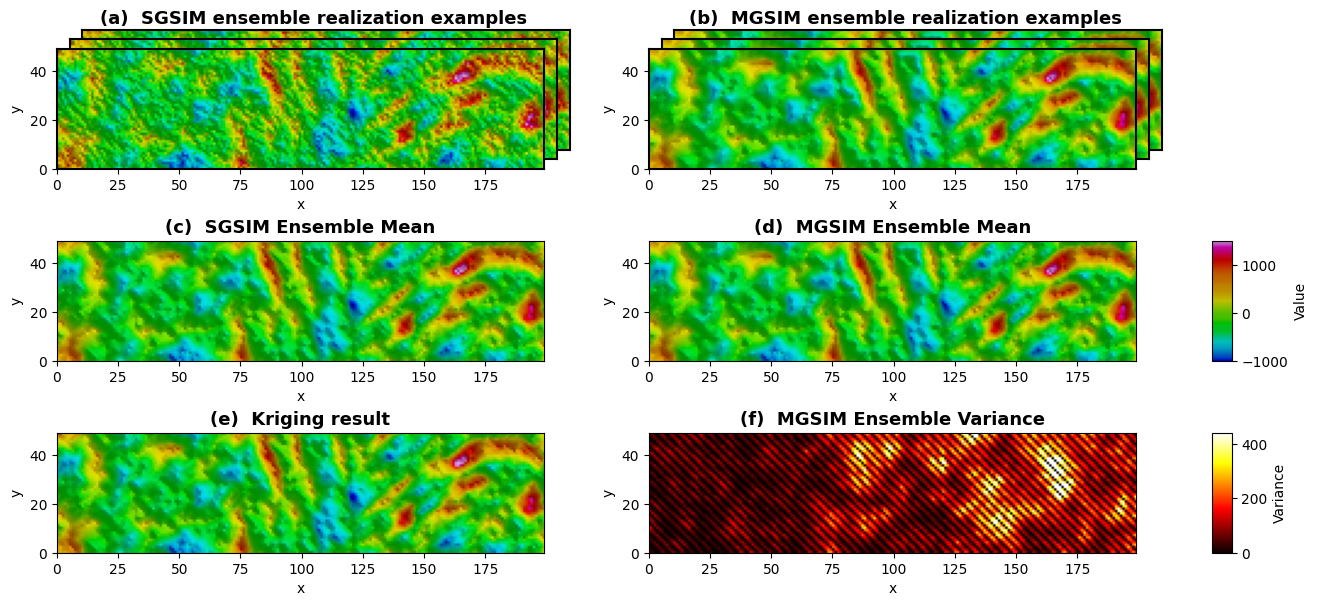

In [17]:
## FIGURE 5: SGSIM vs MGSIM comparison (6-panel, hillshade) ##
## ========================================================= ##

from matplotlib.colors import Normalize, LightSource
from matplotlib.cm import ScalarMappable

ls = LightSource(azdeg=315, altdeg=45)
vmin, vmax = -1000, 1500

extent = [float(ds_mgsim.x.min()), float(ds_mgsim.x.max()),
          float(ds_mgsim.y.min()), float(ds_mgsim.y.max())]

def shade(mat, cmap, vmin, vmax):
    return ls.shade(mat, cmap=cmap, blend_mode='soft', vmin=vmin, vmax=vmax)

def draw_stacked(fig, rect, ds, real_indices, cmap, vmin, vmax, label):
    n = len(real_indices)
    dx, dy = 0.008, 0.008

    for i, ridx in enumerate(real_indices):
        mat = ds['simulated'].sel(realization=ridx).values
        rgb = shade(mat, cmap, vmin, vmax)
        layer = n - 1 - i
        ax = fig.add_axes([
            rect[0] + layer * dx,
            rect[1] + layer * dy,
            rect[2],
            rect[3]
        ])
        ax.imshow(rgb, origin='lower', extent=extent, aspect='equal')
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1.5)

        if i == n - 1:
            ax.set_xlabel('x', fontsize=10)
            ax.set_ylabel('y', fontsize=10)
        else:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel('')
            ax.set_ylabel('')

    title_x = rect[0] + rect[2] / 2 + (n - 1) * dx / 2
    title_y = rect[1] + rect[3] + (n - 1) * dy + 0.005
    fig.text(title_x, title_y, label, ha='center', fontsize=13, fontweight='bold')

# --- Build figure ---
fig = plt.figure(figsize=(16, 12))
cmap = geosoft_cmap

pw, ph = 0.38, 0.10
left_x, right_x = 0.05, 0.42
gap = 0.06

row3_b = 0.06
row2_b = row3_b + ph + gap
row1_b = row2_b + ph + gap

mappable = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
mappable.set_array([])

# (a) SGSIM stacked — 3 realizations
draw_stacked(fig, [left_x, row1_b, pw, ph], ds_sgsim,
             [0, 1, 2], cmap, vmin, vmax, '(a)  SGSIM ensemble realization examples')

# (b) MGSIM stacked — 3 realizations
draw_stacked(fig, [right_x, row1_b, pw, ph], ds_mgsim,
             [0, 1, 2], cmap, vmin, vmax, '(b)  MGSIM ensemble realization examples')

# (c) SGSIM Ensemble Mean
ax_c = fig.add_axes([left_x, row2_b, pw, ph])
ax_c.imshow(shade(sgsim_mean, cmap, vmin, vmax), origin='lower', extent=extent, aspect='equal')
ax_c.set_title('(c)  SGSIM Ensemble Mean', fontsize=13, fontweight='bold')
ax_c.set_xlabel('x', fontsize=10); ax_c.set_ylabel('y', fontsize=10)

# (d) MGSIM Ensemble Mean + value colorbar
ax_d = fig.add_axes([right_x, row2_b, pw, ph])
ax_d.imshow(shade(mgsim_mean, cmap, vmin, vmax), origin='lower', extent=extent, aspect='equal')
ax_d.set_title('(d)  MGSIM Ensemble Mean', fontsize=13, fontweight='bold')
ax_d.set_xlabel('x', fontsize=10); ax_d.set_ylabel('y', fontsize=10)

cbar_ax_val = fig.add_axes([right_x + pw + 0.01, row2_b, 0.012, ph])
fig.colorbar(mappable, cax=cbar_ax_val, label='Value')

# (e) Kriging result
ax_e = fig.add_axes([left_x, row3_b, pw, ph])
ax_e.imshow(shade(krig_pred, cmap, vmin, vmax), origin='lower', extent=extent, aspect='equal')
ax_e.set_title('(e)  Kriging result', fontsize=13, fontweight='bold')
ax_e.set_xlabel('x', fontsize=10); ax_e.set_ylabel('y', fontsize=10)

# (f) MGSIM Ensemble Variance — 'hot' colormap (white = high variance)
var_vmin, var_vmax = 0, np.nanpercentile(mgsim_var, 99)
ax_f = fig.add_axes([right_x, row3_b, pw, ph])
ax_f.imshow(shade(mgsim_var, plt.cm.hot, var_vmin, var_vmax),
            origin='lower', extent=extent, aspect='equal')
ax_f.set_title('(f)  MGSIM Ensemble Variance', fontsize=13, fontweight='bold')
ax_f.set_xlabel('x', fontsize=10); ax_f.set_ylabel('y', fontsize=10)

mappable_var = ScalarMappable(norm=Normalize(vmin=var_vmin, vmax=var_vmax), cmap='hot')
mappable_var.set_array([])
cbar_ax_var = fig.add_axes([right_x + pw + 0.01, row3_b, 0.012, ph])
fig.colorbar(mappable_var, cax=cbar_ax_var, label='Variance')

plt.show()


## Figure 6

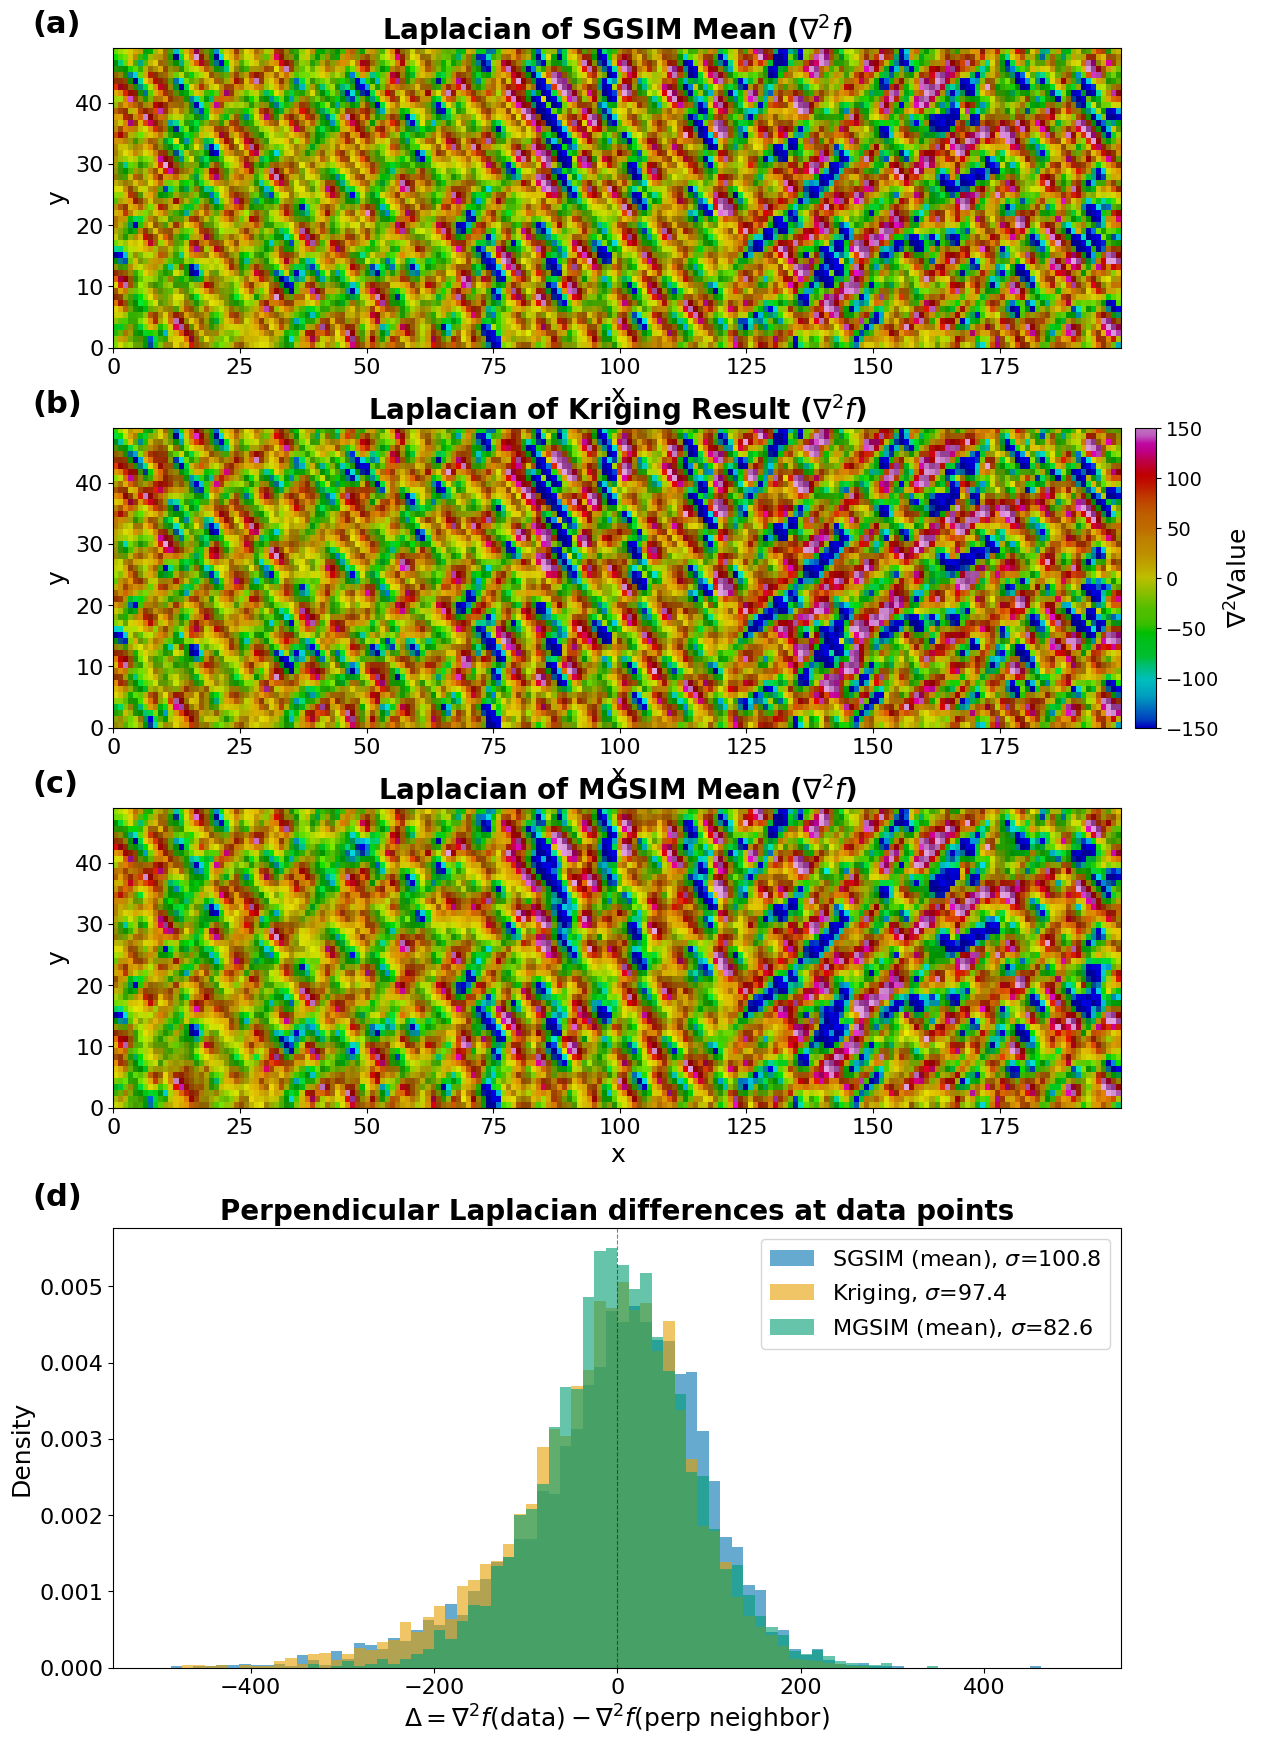

In [49]:
## FIGURE: Laplacian comparison — SGSIM vs Kriging vs MGSIM ##
## ========================================================= ##

import xarray as xr
from matplotlib.colors import Normalize, LightSource
from matplotlib.cm import ScalarMappable

# --- Load data directly ---
base = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/revision01/sherlock/sph_vgram')

sgsim_files = sorted((base / 'standard_geostats' / 'dense').glob('sgsim_realizations_*.nc'))
ds_sgsim_loc = xr.open_mfdataset(sgsim_files, combine='nested', concat_dim='realization')
sgsim_mean = ds_sgsim_loc['simulated'].mean(dim='realization').values

mgsim_files = sorted((base / 'iso_subregions_dense').glob('realizations_*.nc'))
ds_mgsim_loc = xr.open_mfdataset(mgsim_files, combine='nested', concat_dim='realization')
mgsim_mean = ds_mgsim_loc['simulated'].mean(dim='realization').values

ds_krig_loc = xr.open_dataset(base / 'standard_geostats' / 'dense' / 'kriging_result.nc')
krig_pred = ds_krig_loc['kriging_pred'].values

rows, cols = mgsim_mean.shape

extent = [float(ds_mgsim_loc.x.min()), float(ds_mgsim_loc.x.max()),
          float(ds_mgsim_loc.y.min()), float(ds_mgsim_loc.y.max())]

ls = LightSource(azdeg=315, altdeg=45)

# --- Compute Laplacians via np.gradient ---
dx = (extent[1] - extent[0]) / (cols - 1)
dy = (extent[3] - extent[2]) / (rows - 1)

def compute_laplacian(mat):
    df_dy, df_dx = np.gradient(mat, dy, dx)
    d2f_dyy, _ = np.gradient(df_dy, dy, dx)
    _, d2f_dxx = np.gradient(df_dx, dy, dx)
    return d2f_dxx + d2f_dyy

lap_sgsim = compute_laplacian(sgsim_mean)
lap_krig  = compute_laplacian(krig_pred)
lap_mgsim = compute_laplacian(mgsim_mean)

# --- Observation point locations ---
cfg_data = pd.read_csv('/Users/jrines/stanford_gp/research/mx/computers_geosciences/'
                       'multigrid-sgsim/configs/config_iso_subregions_dense_data.csv')
obs = cfg_data[cfg_data['set'] == 1]
obs_rows = obs['y'].astype(int).values
obs_cols = obs['x'].astype(int).values

# --- Perpendicular Laplacian differences ---
# Flight lines are at -45 deg (slope=-1, direction: dx=+1, dy=-1)
# Perpendicular is +45 deg (direction: dx=+1, dy=+1)
# So offsets are (row+k, col+k) and (row-k, col-k)
def perp_lap_diffs(lap, obs_rows, obs_cols, offset=1):
    diffs = []
    nrows, ncols = lap.shape
    for r, c in zip(obs_rows, obs_cols):
        val = lap[r, c]
        if r + offset < nrows and c + offset < ncols:
            diffs.append(val - lap[r + offset, c + offset])
        if r - offset >= 0 and c - offset >= 0:
            diffs.append(val - lap[r - offset, c - offset])
    return np.array(diffs)

# # Combine 1-pixel and 2-pixel offsets into single array per method
# diffs_sgsim = np.concatenate([perp_lap_diffs(lap_sgsim, obs_rows, obs_cols, offset=1),
#                               perp_lap_diffs(lap_sgsim, obs_rows, obs_cols, offset=2)])
# diffs_krig  = np.concatenate([perp_lap_diffs(lap_krig, obs_rows, obs_cols, offset=1),
#                               perp_lap_diffs(lap_krig, obs_rows, obs_cols, offset=2)])
# diffs_mgsim = np.concatenate([perp_lap_diffs(lap_mgsim, obs_rows, obs_cols, offset=1),
#                               perp_lap_diffs(lap_mgsim, obs_rows, obs_cols, offset=2)])
# Only use 1-pixel offset for cleaner comparison
diffs_sgsim = perp_lap_diffs(lap_sgsim, obs_rows, obs_cols, offset=1)
diffs_krig  = perp_lap_diffs(lap_krig, obs_rows, obs_cols, offset=1)
diffs_mgsim = perp_lap_diffs(lap_mgsim, obs_rows, obs_cols, offset=1)

# --- Figure ---
fig = plt.figure(figsize=(14, 20))

lap_vmin, lap_vmax = -150, 150
lap_cmap = geosoft_cmap

lx = 0.10
pw = 0.72
map_ph = 0.15
row_ys = [0.82, 0.63, 0.44]
hist_y, hist_h = 0.16, 0.22

# (a) SGSIM Laplacian
ax_a = fig.add_axes([lx, row_ys[0], pw, map_ph])
rgb_a = ls.shade(lap_sgsim, cmap=lap_cmap, blend_mode='soft', vmin=lap_vmin, vmax=lap_vmax)
ax_a.imshow(rgb_a, origin='lower', extent=extent, aspect='auto')
ax_a.set_title(r'Laplacian of SGSIM Mean ($\nabla^2 f$)', fontsize=20, fontweight='bold')
ax_a.set_xlabel('x', fontsize=18); ax_a.set_ylabel('y', fontsize=18)
ax_a.tick_params(labelsize=16)
ax_a.text(-0.08, 1.05, '(a)', transform=ax_a.transAxes, fontsize=22, fontweight='bold')

# (b) Kriging Laplacian
ax_b = fig.add_axes([lx, row_ys[1], pw, map_ph])
rgb_b = ls.shade(lap_krig, cmap=lap_cmap, blend_mode='soft', vmin=lap_vmin, vmax=lap_vmax)
ax_b.imshow(rgb_b, origin='lower', extent=extent, aspect='auto')
ax_b.set_title(r'Laplacian of Kriging Result ($\nabla^2 f$)', fontsize=20, fontweight='bold')
ax_b.set_xlabel('x', fontsize=18); ax_b.set_ylabel('y', fontsize=18)
ax_b.tick_params(labelsize=16)
ax_b.text(-0.08, 1.05, '(b)', transform=ax_b.transAxes, fontsize=22, fontweight='bold')

# Colorbar next to (b)
val_mappable = ScalarMappable(norm=Normalize(vmin=lap_vmin, vmax=lap_vmax), cmap=lap_cmap)
val_mappable.set_array([])
cbar_ax = fig.add_axes([lx + pw + 0.01, row_ys[1], 0.015, map_ph])
cb = fig.colorbar(val_mappable, cax=cbar_ax)
cb.set_label(r'$\nabla^2$Value', fontsize=18)
cb.ax.tick_params(labelsize=14)

# (c) MGSIM Laplacian
ax_c = fig.add_axes([lx, row_ys[2], pw, map_ph])
rgb_c = ls.shade(lap_mgsim, cmap=lap_cmap, blend_mode='soft', vmin=lap_vmin, vmax=lap_vmax)
ax_c.imshow(rgb_c, origin='lower', extent=extent, aspect='auto')
ax_c.set_title(r'Laplacian of MGSIM Mean ($\nabla^2 f$)', fontsize=20, fontweight='bold')
ax_c.set_xlabel('x', fontsize=18); ax_c.set_ylabel('y', fontsize=18)
ax_c.tick_params(labelsize=16)
ax_c.text(-0.08, 1.05, '(c)', transform=ax_c.transAxes, fontsize=22, fontweight='bold')

# (d) Perpendicular Laplacian differences (1 + 2 pixels combined)
ax_d = fig.add_axes([lx, hist_y, pw, hist_h])
bins = np.linspace(-500, 500, 81)

ax_d.hist(diffs_sgsim, bins=bins, density=True, alpha=0.6,
          color='#0072B2', edgecolor='none',
          label=f'SGSIM (mean), $\\sigma$={diffs_sgsim.std():.1f}')
ax_d.hist(diffs_krig, bins=bins, density=True, alpha=0.6,
          color='#E69F00', edgecolor='none',
          label=f'Kriging, $\\sigma$={diffs_krig.std():.1f}')
ax_d.hist(diffs_mgsim, bins=bins, density=True, alpha=0.6,
          color='#009E73', edgecolor='none',
          label=f'MGSIM (mean), $\\sigma$={diffs_mgsim.std():.1f}')

ax_d.axvline(0, color='k', ls='--', lw=0.8, alpha=0.5)
ax_d.set_xlabel(r'$\Delta = \nabla^2 f(\mathrm{data}) - \nabla^2 f(\mathrm{perp\ neighbor})$', fontsize=18)
ax_d.set_ylabel('Density', fontsize=18)
ax_d.set_title('Perpendicular Laplacian differences at data points',
               fontsize=20, fontweight='bold')
ax_d.legend(fontsize=16)
ax_d.tick_params(labelsize=16)
ax_d.text(-0.08, 1.05, '(d)', transform=ax_d.transAxes, fontsize=22, fontweight='bold')

plt.show()


## Figure 8

Loading 50 batch files...
Loaded: 1000 realizations, grid 248x426


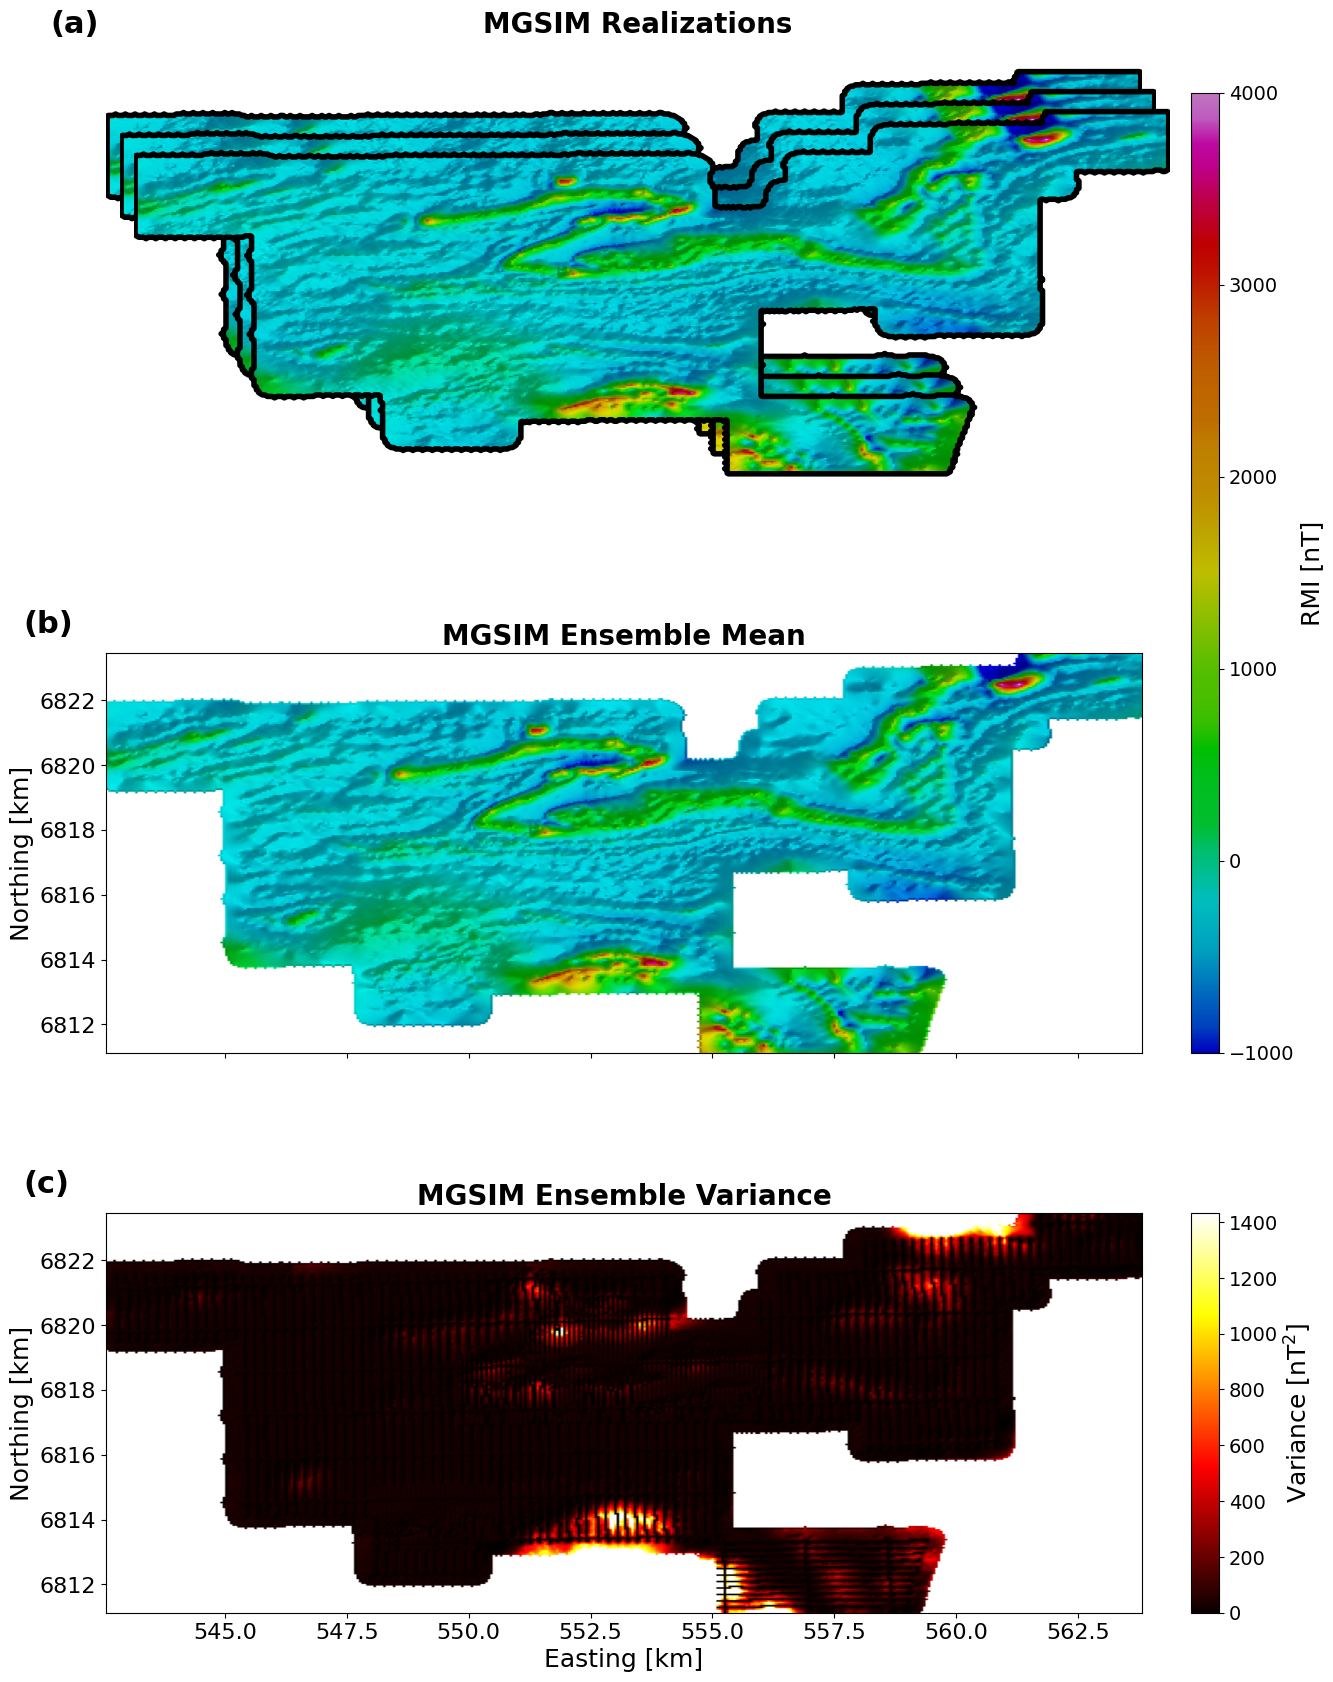

In [68]:
## FIGURE: CSB MGSIM Results — Realizations, Mean, Variance ##
## =========================================================== ##

import xarray as xr
from matplotlib.colors import Normalize, LightSource
from matplotlib.cm import ScalarMappable

# --- Load CSB MGSIM results ---
csb_dir = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/'
               'revision01/sherlock/csb/csb_sph_iso')
csb_files = sorted(csb_dir.glob('realizations_*.nc'))
print(f"Loading {len(csb_files)} batch files...")
ds_csb = xr.open_mfdataset(csb_files, combine='nested', concat_dim='realization')
ds_csb = ds_csb.sortby('realization')
sim = ds_csb['simulated']  # (1000, 248, 426)
print(f"Loaded: {sim.shape[0]} realizations, grid {sim.shape[1]}x{sim.shape[2]}")

# --- Compute summary maps ---
csb_mean = sim.mean(dim='realization').values
csb_var  = sim.var(dim='realization').values
rows_csb, cols_csb = csb_mean.shape

# --- Coordinates in km ---
x_km = ds_csb.x.values / 1000.0
y_km = ds_csb.y.values / 1000.0
extent_csb = [x_km.min(), x_km.max(), y_km.min(), y_km.max()]

# --- Hillshade helpers ---
ls = LightSource(azdeg=45, altdeg=45)

def shade_transparent(mat, cmap, vmin, vmax):
    nan_mask = np.isnan(mat)
    filled = np.where(nan_mask, 0, mat)
    rgb = ls.shade(filled, cmap=cmap, blend_mode='soft', vmin=vmin, vmax=vmax)
    rgb[nan_mask] = [1, 1, 1, 0]
    return rgb

def shade_masked(mat, cmap, vmin, vmax):
    nan_mask = np.isnan(mat)
    filled = np.where(nan_mask, 0, mat)
    rgb = ls.shade(filled, cmap=cmap, blend_mode='soft', vmin=vmin, vmax=vmax)
    rgb[nan_mask] = [1, 1, 1, 1]
    return rgb

# --- Color limits ---
vmin_val, vmax_val = -1000, 4000
vmin_var, vmax_var = 0, np.nanpercentile(csb_var, 99)

# --- Padded extent for contour (so outline closes at array edges) ---
px = (extent_csb[1] - extent_csb[0]) / (cols_csb - 1)
py = (extent_csb[3] - extent_csb[2]) / (rows_csb - 1)
padded_extent = [extent_csb[0] - px, extent_csb[1] + px,
                 extent_csb[2] - py, extent_csb[3] + py]

# --- Figure ---
fig = plt.figure(figsize=(14, 20))

lx = 0.08
pw = 0.74
ph = 0.20
cb_x = lx + pw + 0.035
cb_w = 0.02

# ===== (a) Fanned-out realizations =====
# Back layers at top-left, front layer at bottom-right
real_indices = [0, 42, 200]
n_stack = len(real_indices)
dx_off, dy_off = 0.01, 0.01
stack_y0 = 0.70

for i, ridx in enumerate(real_indices):
    mat = sim.sel(realization=ridx).values
    rgb = shade_transparent(mat, geosoft_cmap, vmin_val, vmax_val)

    # i=0 drawn first (back, top-left), i=n-1 drawn last (front, bottom-right)
    ax = fig.add_axes([lx + i * dx_off,
                       stack_y0 + (n_stack - 1 - i) * dy_off,
                       pw, ph])
    ax.set_facecolor('none')
    ax.imshow(rgb, origin='lower', extent=extent_csb, aspect='auto')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Pad valid mask so contour closes at array edges
    valid_mask = (~np.isnan(mat)).astype(float)
    padded = np.pad(valid_mask, 1, mode='constant', constant_values=0)
    ax.contour(padded, levels=[0.5], colors='black', linewidths=4,
               extent=padded_extent, origin='lower')

# Title and label
title_x = lx + pw / 2 + (n_stack - 1) * dx_off / 2
title_y = stack_y0 + ph + (n_stack - 1) * dy_off + 0.01
fig.text(title_x, title_y, 'MGSIM Realizations',
         ha='center', fontsize=20, fontweight='bold')
fig.text(lx - 0.04, stack_y0 + ph + (n_stack - 1) * dy_off + 0.01,
         '(a)', fontsize=22, fontweight='bold')

# ===== (b) Ensemble mean =====
mean_y0 = 0.42
ax_b = fig.add_axes([lx, mean_y0, pw, ph])
rgb_b = shade_masked(csb_mean, geosoft_cmap, vmin_val, vmax_val)
ax_b.imshow(rgb_b, origin='lower', extent=extent_csb, aspect='auto')
ax_b.set_ylabel('Northing [km]', fontsize=18)
ax_b.set_title('MGSIM Ensemble Mean', fontsize=20, fontweight='bold')
ax_b.tick_params(labelsize=16)
ax_b.set_xticklabels([])
ax_b.text(-0.08, 1.05, '(b)', transform=ax_b.transAxes,
          fontsize=22, fontweight='bold')

# Shared colorbar for (a) and (b)
sm_val = ScalarMappable(norm=Normalize(vmin=vmin_val, vmax=vmax_val), cmap=geosoft_cmap)
sm_val.set_array([])
cbar_val_ax = fig.add_axes([cb_x, mean_y0, cb_w,
                            stack_y0 + ph - mean_y0])
cb_val = fig.colorbar(sm_val, cax=cbar_val_ax)
cb_val.set_label('RMI [nT]', fontsize=18)
cb_val.ax.tick_params(labelsize=14)

# ===== (c) Variance =====
var_y0 = 0.14
ax_c = fig.add_axes([lx, var_y0, pw, ph])
rgb_c = shade_masked(csb_var, plt.cm.hot, vmin_var, vmax_var)
ax_c.imshow(rgb_c, origin='lower', extent=extent_csb, aspect='auto')
ax_c.set_xlabel('Easting [km]', fontsize=18)
ax_c.set_ylabel('Northing [km]', fontsize=18)
ax_c.set_title('MGSIM Ensemble Variance', fontsize=20, fontweight='bold')
ax_c.tick_params(labelsize=16)
ax_c.text(-0.08, 1.05, '(c)', transform=ax_c.transAxes,
          fontsize=22, fontweight='bold')

# Variance colorbar
sm_var = ScalarMappable(norm=Normalize(vmin=vmin_var, vmax=vmax_var), cmap='hot')
sm_var.set_array([])
cbar_var_ax = fig.add_axes([cb_x, var_y0, cb_w, ph])
cb_var = fig.colorbar(sm_var, cax=cbar_var_ax)
cb_var.set_label('Variance [nT$^2$]', fontsize=18)
cb_var.ax.tick_params(labelsize=14)

plt.show()


## Figure A1 (prospectivity)

In [72]:
# =============================================================================
# Bayesian Prospectivity — Cape Smith Belt MGSIM Ensemble
# Part 1: Data loading & posterior computation
# =============================================================================
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import gaussian_kde
from pathlib import Path
from datetime import datetime

RESULTS_DIR = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences'
                   '/revision01/sherlock/csb/csb_sph_iso')
DATA_DIR = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/data')

# --- 1. Load MGSIM ensemble ---
print(f"[{datetime.now():%H:%M:%S}] Loading ensemble...")
nc_files = sorted(RESULTS_DIR.glob('realizations_*.nc'))
ds = xr.open_mfdataset(nc_files, combine='nested', concat_dim='realization')
sim = ds['simulated'].values                       # (1000, 248, 426)
x_coords, y_coords = ds['x'].values, ds['y'].values
n_real, rows, cols = sim.shape
x_km, y_km = x_coords / 1000, y_coords / 1000
extent_km = [x_km[0], x_km[-1], y_km[0], y_km[-1]]
ens_mean = np.nanmean(sim, axis=0)
valid_mask = np.isfinite(sim[0])
print(f"  {n_real} realizations, {rows}x{cols}")

# --- 2. Match lithology drill holes → flight-line RMI values ---
print(f"[{datetime.now():%H:%M:%S}] Matching lithology → RMI...")
df_lith = pd.read_csv(DATA_DIR / 'lithologies_updated.csv')
df_csb  = pd.read_csv(DATA_DIR / 'csb_xyvmmc.csv')
df_fl   = df_csb[df_csb['fl_mask'] == 1]
obs_x, obs_y, obs_rmi = df_fl['x'].values, df_fl['y'].values, df_fl['val'].values

intr  = df_lith[df_lith['intrusive'] == 1]
nintr = df_lith[df_lith['intrusive'] == 0]
half = 25.0  # gridsize/2 = 50/2

int_flag  = np.zeros(len(obs_x), dtype=bool)
nint_flag = np.zeros(len(obs_x), dtype=bool)
# Loop over lithology points (646) rather than obs points (17k)
for lx_arr, ly_arr, flag in [(intr['x'].values, intr['y'].values, int_flag),
                              (nintr['x'].values, nintr['y'].values, nint_flag)]:
    for j in range(len(lx_arr)):
        mask = ((obs_x >= lx_arr[j] - half) & (obs_x <= lx_arr[j] + half) &
                (obs_y >= ly_arr[j] - half) & (obs_y <= ly_arr[j] + half))
        flag |= mask

label_int  = int_flag
label_nint = nint_flag & ~int_flag
rmi_int  = obs_rmi[label_int]
rmi_nint = obs_rmi[label_nint]

n_lab = label_int.sum() + label_nint.sum()
prior_i  = float(label_int.sum())  / n_lab
prior_ni = float(label_nint.sum()) / n_lab
print(f"  Prior(int)={prior_i:.4f}, Prior(nint)={prior_ni:.4f}")
print(f"  N_int={len(rmi_int)}, N_nint={len(rmi_nint)}")

# --- 3. KDE likelihoods ---
kde_i  = gaussian_kde(rmi_int)
kde_ni = gaussian_kde(rmi_nint)

# --- 4. Compute posteriors for all 1000 realizations ---
print(f"[{datetime.now():%H:%M:%S}] Computing posteriors...")
post_all = np.full((n_real, rows, cols), np.nan, dtype=np.float32)
for r in range(n_real):
    v = np.isfinite(sim[r])
    vals = sim[r][v]
    li  = kde_i(vals)  * prior_i
    lni = kde_ni(vals) * prior_ni
    d = li + lni; d[d == 0] = 1e-300
    post_all[r][v] = (li / d).astype(np.float32)
    if r % 200 == 0:
        print(f"  {r}/{n_real}")


# --- 5. Logit-space aggregation → mean & variance ---
eps_c = 1e-6
P = np.clip(post_all, eps_c, 1 - eps_c)
L = np.log(P) - np.log1p(-P)             # logits
mu_L  = np.nanmean(L, axis=0)
var_L = np.nanvar(L, axis=0)
p_sig = 1 / (1 + np.exp(-mu_L))          # sigmoid of mean logit
gp = p_sig * (1 - p_sig)
p_mean = p_sig + 0.5 * gp * (1 - 2*p_sig) * var_L   # delta-method mean
p_var  = gp**2 * var_L                                # delta-method variance

# --- 6. Posterior from ensemble mean RMI ---
post_ens_mean = np.full((rows, cols), np.nan)
v_em_mask = np.isfinite(ens_mean)
v_em = ens_mean[v_em_mask]
li_em  = kde_i(v_em)  * prior_i
lni_em = kde_ni(v_em) * prior_ni
d_em = li_em + lni_em; d_em[d_em == 0] = 1e-300
post_ens_mean[v_em_mask] = li_em / d_em

print(f"[{datetime.now():%H:%M:%S}] Done.")


[21:51:03] Loading ensemble...


/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_4601/2239211527.py:25: RuntimeWarning: Mean of empty slice
  ens_mean = np.nanmean(sim, axis=0)


  1000 realizations, 248x426
[21:51:03] Matching lithology → RMI...
  Prior(int)=0.7917, Prior(nint)=0.2083
  N_int=19, N_nint=5
[21:51:03] Computing posteriors...
  0/1000
  200/1000
  400/1000
  600/1000
  800/1000


/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_4601/2239211527.py:83: RuntimeWarning: Mean of empty slice
  mu_L  = np.nanmean(L, axis=0)


[21:51:11] Done.


/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_4601/2239211527.py:84: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_L = np.nanvar(L, axis=0)


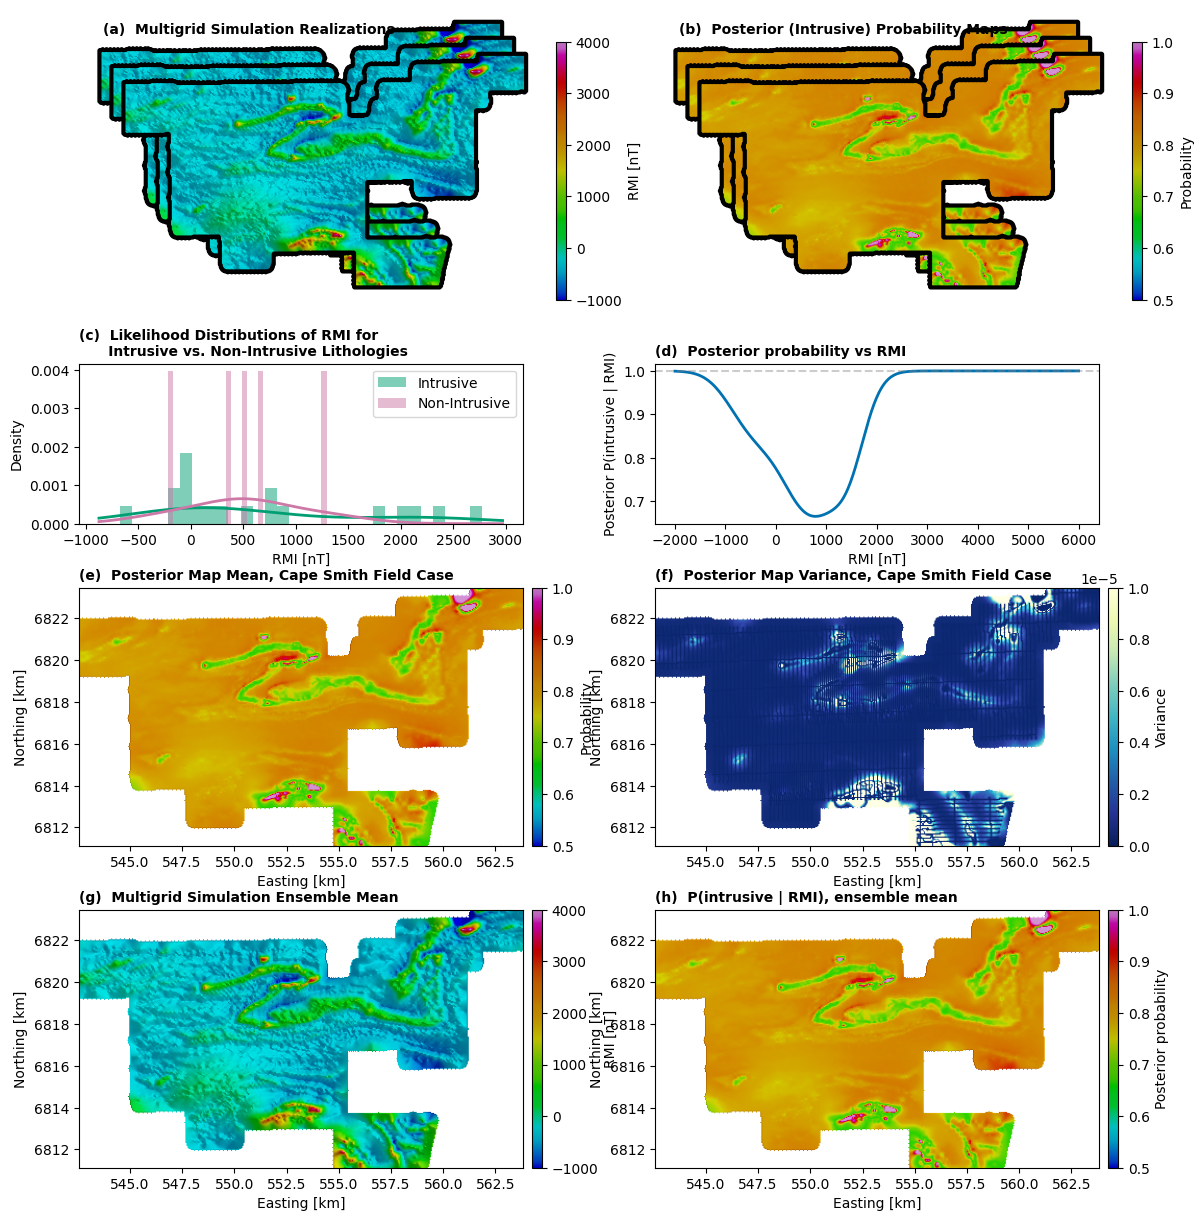

In [79]:
# =============================================================================
# Bayesian Prospectivity Figure — 8 panels
# =============================================================================
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LightSource
from utils import geosoft_cmap_k65
geosoft_cmap = geosoft_cmap_k65()
ls = LightSource(azdeg=120, altdeg=45)

# --- helpers ---
def shade_map(data, cmap, vmin, vmax):
    rgb = ls.shade(np.where(valid_mask, data, 0), cmap=cmap,
                   blend_mode='soft', vmin=vmin, vmax=vmax)
    rgb[~valid_mask] = [1, 1, 1, 0]
    return rgb

def add_outline(ax, lw=2):
    padded = np.pad(valid_mask, 1, constant_values=False)
    dx = (extent_km[1] - extent_km[0]) / (cols - 1)
    dy = (extent_km[3] - extent_km[2]) / (rows - 1)
    pad_ext = [extent_km[0]-dx/2, extent_km[1]+dx/2,
               extent_km[2]-dy/2, extent_km[3]+dy/2]
    ax.contour(padded.astype(float), levels=[0.5], colors='k',
               linewidths=lw, extent=pad_ext, origin='lower')

def strip_ax(ax):
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_facecolor('none'); ax.patch.set_alpha(0)

def add_cb(fig, ax, cmap, vmin, vmax, label):
    pos = ax.get_position()
    cax = fig.add_axes([pos.x1 + 0.008, pos.y0, 0.008, pos.height])
    sm = ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, label=label)

def map_axes(fig, ax, data, cmap, vmin, vmax, title, cb_label):
    rgb = shade_map(data, cmap, vmin, vmax)
    ax.imshow(rgb, origin='lower', extent=extent_km, aspect='auto')
    ax.set_xlabel('Easting [km]'); ax.set_ylabel('Northing [km]')
    ax.set_title(title, fontsize=10, fontweight='bold', loc='left')
    add_cb(fig, ax, cmap, vmin, vmax, cb_label)

# --- layout ---
fig = plt.figure(figsize=(12, 16))
pw = 0.37
lx, rx = 0.07, 0.55
asp = (x_km[-1] - x_km[0]) / (y_km[-1] - y_km[0])
ph = pw * 12 / (asp * 16)   # map height preserving aspect ratio
hist_h = 0.10
gap = 0.04

# row y-positions (from bottom up)
r4_y = 0.05
r3_y = r4_y + ph + gap
r2_y = r3_y + ph + gap       # histogram row
r1_y = r2_y + hist_h + gap   # fanned row

# fanning params
n_stack = 3
dx_off, dy_off = 0.01, 0.01
real_indices = [0, 42, 200]

# ---- (a) Fanned MGSIM realizations ----
for i, ri in enumerate(real_indices):
    ax = fig.add_axes([lx + i*dx_off,
                       r1_y + (n_stack-1-i)*dy_off, pw, ph])
    ax.imshow(shade_map(sim[ri], geosoft_cmap, -1000, 4000),
              origin='lower', extent=extent_km, aspect='auto')
    add_outline(ax, lw=3); strip_ax(ax)
    if i == n_stack - 1:
        ax.set_title('(a)  Multigrid Simulation Realizations',
                     fontsize=10, fontweight='bold', loc='left')
        add_cb(fig, ax, geosoft_cmap, -1000, 4000, 'RMI [nT]')

# ---- (b) Fanned posterior maps ----
for i, ri in enumerate(real_indices):
    ax = fig.add_axes([rx + i*dx_off,
                       r1_y + (n_stack-1-i)*dy_off, pw, ph])
    ax.imshow(shade_map(post_all[ri], geosoft_cmap, 0.5, 1.0),
              origin='lower', extent=extent_km, aspect='auto')
    add_outline(ax, lw=3); strip_ax(ax)
    if i == n_stack - 1:
        ax.set_title('(b)  Posterior (Intrusive) Probability Maps',
                     fontsize=10, fontweight='bold', loc='left')
        add_cb(fig, ax, geosoft_cmap, 0.5, 1.0, 'Probability')

# ---- (c) Likelihood distributions ----
ax_c = fig.add_axes([lx, r2_y, pw, hist_h])
bins = np.linspace(-500, 2500, 40)
ax_c.hist(rmi_int,  bins=30, density=True, alpha=0.5,
          color='#009E73', label='Intrusive')
ax_c.hist(rmi_nint, bins=30, density=True, alpha=0.5,
          color='#CC79A7', label='Non-Intrusive')
xx = np.linspace(min(rmi_int.min(), rmi_nint.min()) - 200,
                 max(rmi_int.max(), rmi_nint.max()) + 200, 300)
ax_c.plot(xx, kde_i(xx),  color='#009E73', lw=2)
ax_c.plot(xx, kde_ni(xx), color='#CC79A7', lw=2)
ax_c.set_xlabel('RMI [nT]'); ax_c.set_ylabel('Density')
ax_c.set_title('(c)  Likelihood Distributions of RMI for\n'
               '      Intrusive vs. Non-Intrusive Lithologies',
               fontsize=10, fontweight='bold', loc='left')
ax_c.legend()

# ---- (d) Posterior probability vs RMI ----
ax_d = fig.add_axes([rx, r2_y, pw, hist_h])
xx_p = np.linspace(-2000, 6000, 500)
li_c  = kde_i(xx_p)  * prior_i
lni_c = kde_ni(xx_p) * prior_ni
d_c = li_c + lni_c; d_c[d_c == 0] = 1e-300
ax_d.plot(xx_p, li_c / d_c, color='#0072B2', lw=2)
ax_d.axhline(1.0, ls='--', color='gray', alpha=0.4)
ax_d.set_xlabel('RMI [nT]')
ax_d.set_ylabel('Posterior P(intrusive | RMI)')
ax_d.set_title('(d)  Posterior probability vs RMI',
               fontsize=10, fontweight='bold', loc='left')

# ---- (e) Posterior map mean ----
ax_e = fig.add_axes([lx, r3_y, pw, ph])
map_axes(fig, ax_e, p_mean, geosoft_cmap, 0.5, 1.0,
         '(e)  Posterior Map Mean, Cape Smith Field Case', 'Probability')

# ---- (f) Posterior map variance ----
ax_f = fig.add_axes([rx, r3_y, pw, ph])
map_axes(fig, ax_f, p_var, plt.cm.YlGnBu_r, 0, 0.00001,
         '(f)  Posterior Map Variance, Cape Smith Field Case', 'Variance')

# ---- (g) Ensemble mean RMI ----
ax_g = fig.add_axes([lx, r4_y, pw, ph])
map_axes(fig, ax_g, ens_mean, geosoft_cmap, -1000, 4000,
         '(g)  Multigrid Simulation Ensemble Mean', 'RMI [nT]')

# ---- (h) P(intrusive | ensemble mean) ----
ax_h = fig.add_axes([rx, r4_y, pw, ph])
map_axes(fig, ax_h, post_ens_mean, geosoft_cmap, 0.5, 1.0,
         '(h)  P(intrusive | RMI), ensemble mean', 'Posterior probability')

plt.show()


## NEW FIGURE: error maps

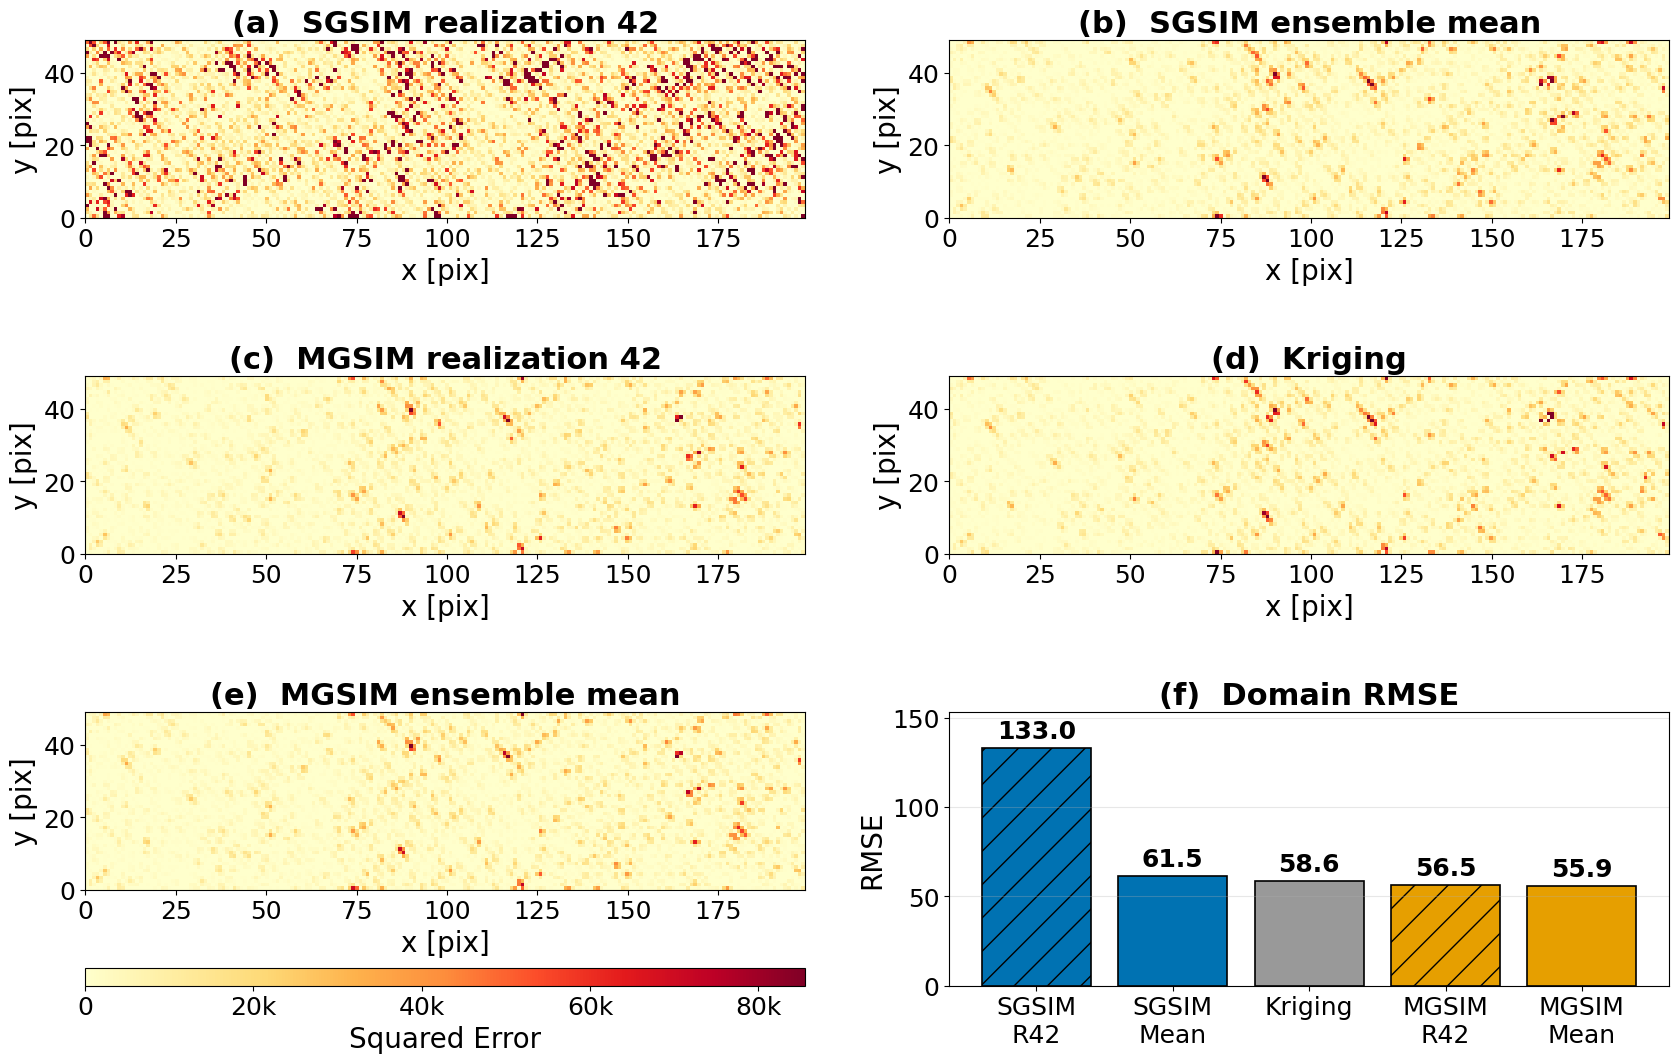


RMSE summary:
  SGSIM R42           133.0
  SGSIM Mean           61.5
  Kriging              58.6
  MGSIM R42            56.5
  MGSIM Mean           55.9


In [31]:
## FIGURE: Pixel-wise Squared Error — 3×2 layout ##
## ============================================== ##

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# --- Load ground truth ---
gt_path = '/Users/jrines/stanford_gp/research/mx/computers_geosciences/data/synthetic_magnetic_groundtruth.csv'
df_gt = pd.read_csv(gt_path)
ground_truth = df_gt['val'].values.reshape(
    df_gt['y'].nunique(), df_gt['x'].nunique()
)

extent = [float(ds_mgsim.x.min()), float(ds_mgsim.x.max()),
          float(ds_mgsim.y.min()), float(ds_mgsim.y.max())]

# --- Compute squared errors ---
sgsim_r42  = ds_sgsim['simulated'].sel(realization=42).values
mgsim_r42  = ds_mgsim['simulated'].sel(realization=42).values

se_sgsim_r42  = (sgsim_r42 - ground_truth) ** 2
se_sgsim_mean = (sgsim_mean - ground_truth) ** 2
se_krig       = (krig_pred - ground_truth) ** 2
se_mgsim_r42  = (mgsim_r42 - ground_truth) ** 2
se_mgsim_mean = (mgsim_mean - ground_truth) ** 2

all_se = np.concatenate([se_sgsim_r42.ravel(), se_sgsim_mean.ravel(),
                         se_krig.ravel(), se_mgsim_r42.ravel(),
                         se_mgsim_mean.ravel()])
se_vmax = np.nanpercentile(all_se, 99)

# --- RMSE ---
rmse_vals = [
    np.sqrt(np.nanmean(se_sgsim_r42)),
    np.sqrt(np.nanmean(se_sgsim_mean)),
    np.sqrt(np.nanmean(se_krig)),
    np.sqrt(np.nanmean(se_mgsim_r42)),
    np.sqrt(np.nanmean(se_mgsim_mean)),
]
bar_labels = ['SGSIM\nR42', 'SGSIM\nMean', 'Kriging', 'MGSIM\nR42', 'MGSIM\nMean']
bar_colors = ['#0072B2', '#0072B2', '#999999', '#E69F00', '#E69F00']
bar_hatches = ['/', '', '', '/', '']

# --- Layout ---
fig_w, fig_h = 18, 12
fig = plt.figure(figsize=(fig_w, fig_h))

lx, rx = 0.06, 0.54
pw = 0.40

data_aspect = (extent[3] - extent[2]) / (extent[1] - extent[0])
ph = pw * data_aspect * (fig_w / fig_h)

row_y = [0.72, 0.44, 0.16]
cbar_y = 0.08
cmap_se = 'YlOrRd'

panels = [
    (0, 0, se_sgsim_r42,  '(a)  SGSIM realization 42'),
    (0, 1, se_sgsim_mean, '(b)  SGSIM ensemble mean'),
    (1, 0, se_mgsim_r42,  '(c)  MGSIM realization 42'),
    (1, 1, se_krig,       '(d)  Kriging'),
    (2, 0, se_mgsim_mean, '(e)  MGSIM ensemble mean'),
]

im = None
for row, col, se, title in panels:
    x = lx if col == 0 else rx
    ax = fig.add_axes([x, row_y[row], pw, ph])
    im = ax.imshow(se, origin='lower', extent=extent, aspect='auto',
                   cmap=cmap_se, vmin=0, vmax=se_vmax)
    ax.set_title(title, fontsize=22, fontweight='bold')
    ax.set_xlabel('x [pix]', fontsize=20)
    ax.set_ylabel('y [pix]', fontsize=20)
    ax.tick_params(labelsize=18)

# Colorbar — horizontal, below bottom-left panel
cbar_ax = fig.add_axes([lx, cbar_y, pw, 0.015])
cb = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cb.set_ticks([0, 20000, 40000, 60000, 80000])
cb.set_ticklabels(['0', '20k', '40k', '60k', '80k'])
cb.set_label('Squared Error', fontsize=20)
cb.ax.tick_params(labelsize=18)

# (f) RMSE bar chart — extends from colorbar level up to same top as panel (e)
bar_bottom = cbar_y
bar_top = row_y[2] + ph
ax_bar = fig.add_axes([rx, bar_bottom, pw, bar_top - bar_bottom])
bars = ax_bar.bar(range(len(rmse_vals)), rmse_vals, color=bar_colors,
                  edgecolor='black', linewidth=1.2)
for bar, hatch in zip(bars, bar_hatches):
    bar.set_hatch(hatch)

ax_bar.set_xticks(range(len(rmse_vals)))
ax_bar.set_xticklabels(bar_labels, fontsize=18)
ax_bar.set_ylabel('RMSE', fontsize=20)
ax_bar.set_title('(f)  Domain RMSE', fontsize=22, fontweight='bold')
ax_bar.tick_params(axis='y', labelsize=18)
ax_bar.grid(axis='y', alpha=0.3)

for j, v in enumerate(rmse_vals):
    ax_bar.text(j, v + max(rmse_vals) * 0.02, f'{v:.1f}',
                ha='center', va='bottom', fontsize=18, fontweight='bold')
ax_bar.set_ylim(0, max(rmse_vals) * 1.15)

plt.show()

# --- Print summary ---
print("\nRMSE summary:")
for label, rmse in zip(bar_labels, rmse_vals):
    print(f"  {label.replace(chr(10), ' '):<16} {rmse:>8.1f}")


## New figure (CSB validation)

Loading 50 holdout batch files...
Loaded: (1000, 248, 426)
Holdout observations: 459 points
Grid column indices: [129, 222, 254]
Actual grid x-values: [549007.731488, 553657.731488, 555257.731488]


/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_4601/1155612961.py:106: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(profiles, axis=0)
/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_4601/1155612961.py:106: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(profiles, axis=0)
/var/folders/mr/bgbp776x687gs3ndy2tgrybr0000gn/T/ipykernel_4601/1155612961.py:106: RuntimeWarning: Mean of empty slice
  mean_profile = np.nanmean(profiles, axis=0)


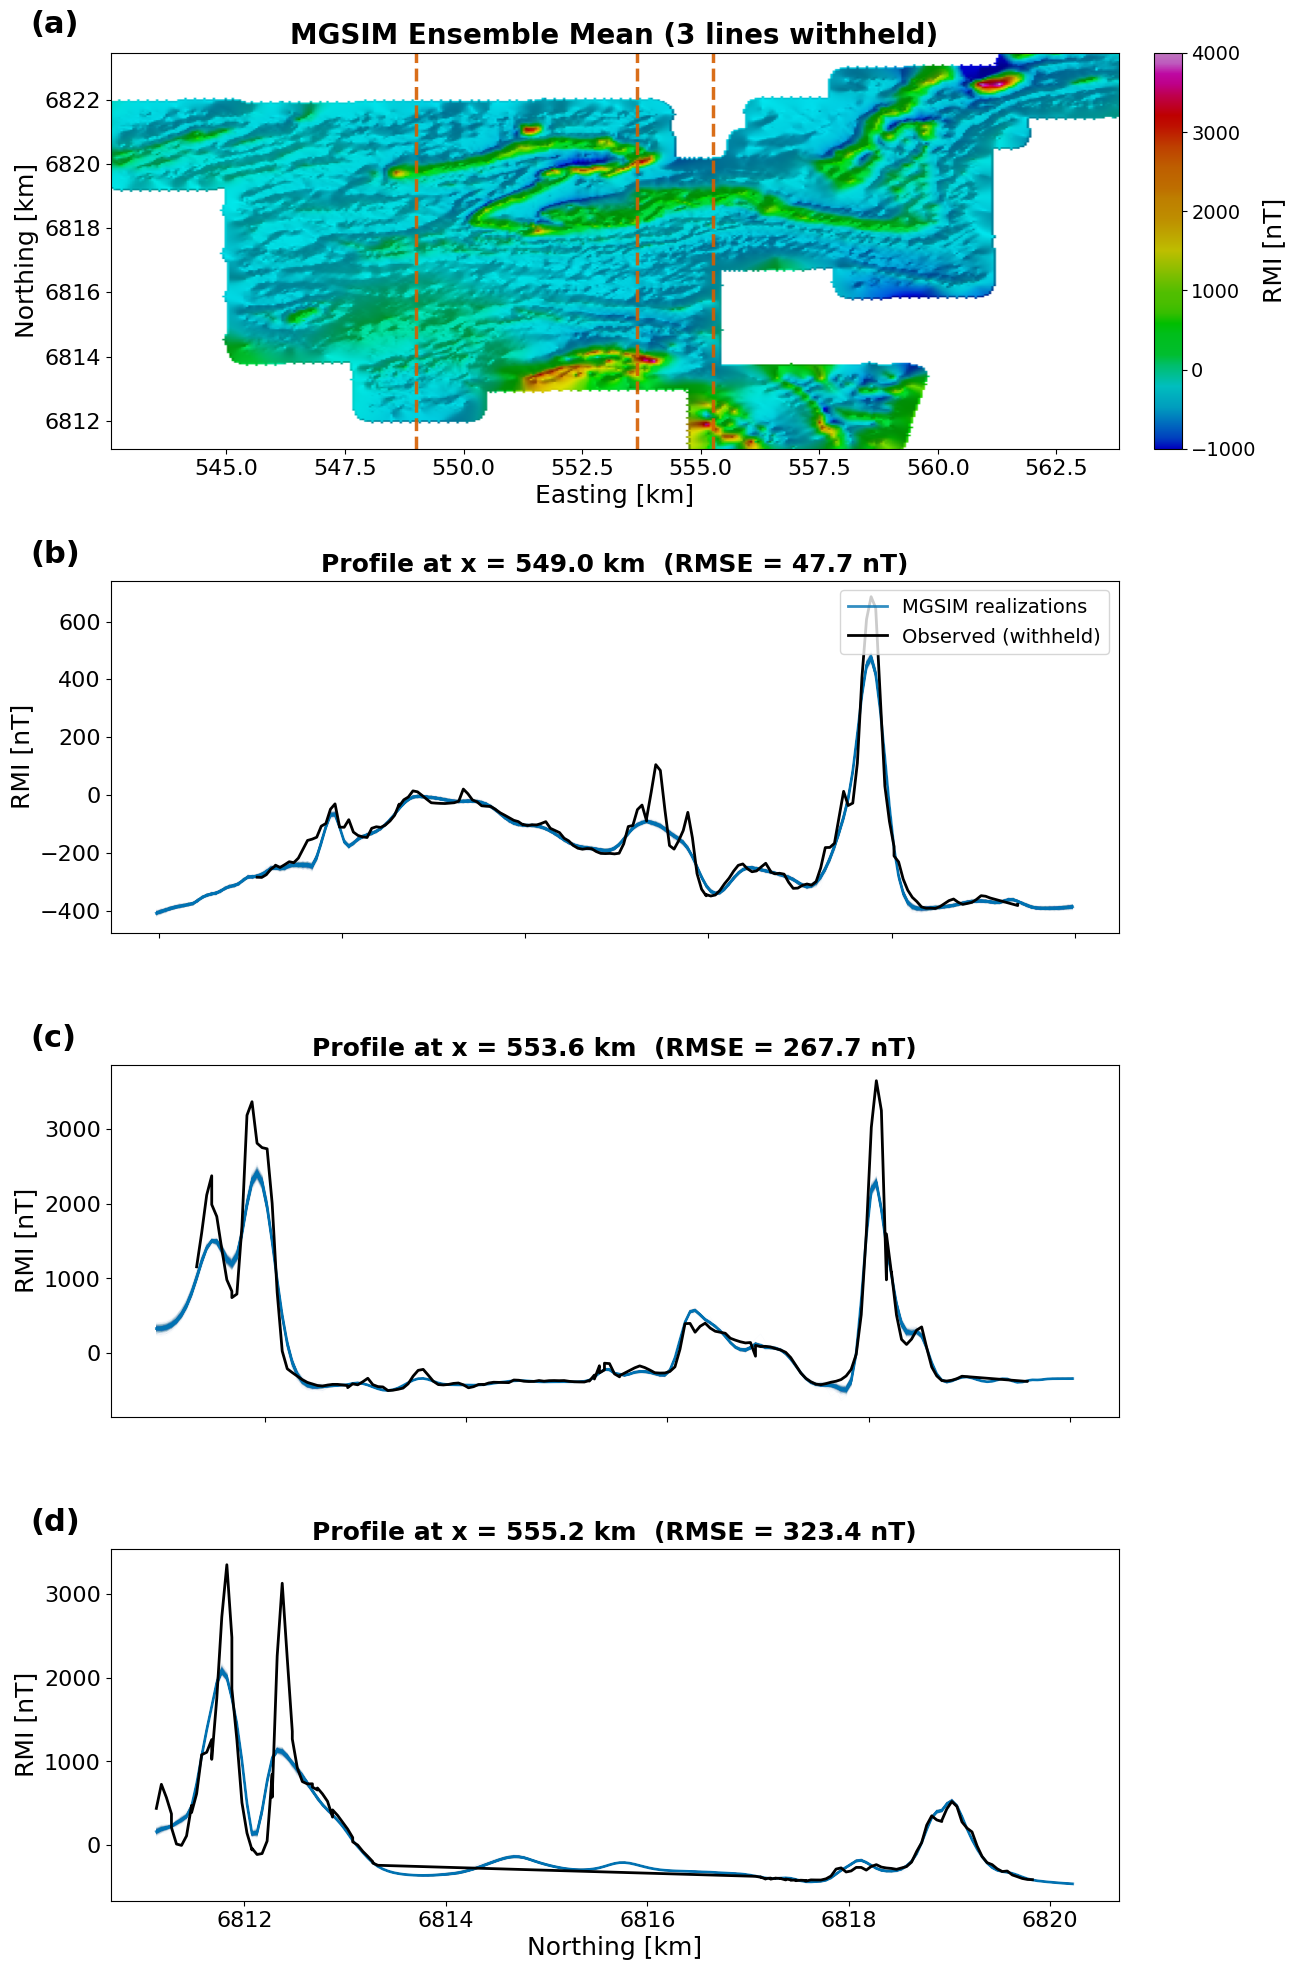

In [69]:
## FIGURE: CSB Holdout Validation — 3 Lines Out ##
## ============================================== ##

import xarray as xr
from matplotlib.colors import Normalize, LightSource
from matplotlib.cm import ScalarMappable

# --- Load 3-lines-out MGSIM results ---
ho_dir = Path('/Users/jrines/stanford_gp/research/mx/computers_geosciences/'
              'revision01/sherlock/csb/csb_sph_iso_3linesout')
ho_files = sorted(ho_dir.glob('realizations_*.nc'))
print(f"Loading {len(ho_files)} holdout batch files...")
ds_ho = xr.open_mfdataset(ho_files, combine='nested', concat_dim='realization')
ds_ho = ds_ho.sortby('realization')
sim_ho = ds_ho['simulated']  # (1000, 248, 426)
print(f"Loaded: {sim_ho.shape}")

ho_mean = sim_ho.mean(dim='realization').values
rows_ho, cols_ho = ho_mean.shape

# Coordinates
x_m = ds_ho.x.values        # in meters
y_m = ds_ho.y.values         # in meters
x_km = x_m / 1000.0
y_km = y_m / 1000.0
extent_ho = [x_km.min(), x_km.max(), y_km.min(), y_km.max()]

# --- Load ground truth (held-out observations) ---
df_holdout = pd.read_csv('/Users/jrines/stanford_gp/research/mx/computers_geosciences/'
                         'data/csb_holdout_3lines.csv')
print(f"Holdout observations: {len(df_holdout)} points")

# --- Held-out line x-values and grid column indices ---
holdout_x_vals = [549000, 553650, 555250]
col_indices = [int(np.argmin(np.abs(x_m - xv))) for xv in holdout_x_vals]
print(f"Grid column indices: {col_indices}")
print(f"Actual grid x-values: {[x_m[ci] for ci in col_indices]}")

# --- Hillshade ---
ls = LightSource(azdeg=45, altdeg=45)

def shade_masked(mat, cmap, vmin, vmax):
    nan_mask = np.isnan(mat)
    filled = np.where(nan_mask, 0, mat)
    rgb = ls.shade(filled, cmap=cmap, blend_mode='soft', vmin=vmin, vmax=vmax)
    rgb[nan_mask] = [1, 1, 1, 1]
    return rgb

vmin_val, vmax_val = -1000, 4000

# --- Figure ---
fig = plt.figure(figsize=(14, 22))

lx = 0.10
pw = 0.72
cb_x = lx + pw + 0.025
cb_w = 0.02

# ===== (a) Map: ensemble mean with held-out lines =====
map_y0, map_ph = 0.76, 0.18
ax_map = fig.add_axes([lx, map_y0, pw, map_ph])
rgb_map = shade_masked(ho_mean, geosoft_cmap, vmin_val, vmax_val)
ax_map.imshow(rgb_map, origin='lower', extent=extent_ho, aspect='auto')

# Overlay the 3 held-out lines
line_colors = ['#D55E00', '#D55E00', '#D55E00']  # vermillion
for xv in holdout_x_vals:
    ax_map.axvline(xv / 1000.0, color='#D55E00', linewidth=2.5, linestyle='--', alpha=0.9)

ax_map.set_ylabel('Northing [km]', fontsize=18)
ax_map.set_xlabel('Easting [km]', fontsize=18)
ax_map.set_title('MGSIM Ensemble Mean (3 lines withheld)', fontsize=20, fontweight='bold')
ax_map.tick_params(labelsize=16)
ax_map.text(-0.08, 1.05, '(a)', transform=ax_map.transAxes,
            fontsize=22, fontweight='bold')

# Colorbar
sm_val = ScalarMappable(norm=Normalize(vmin=vmin_val, vmax=vmax_val), cmap=geosoft_cmap)
sm_val.set_array([])
cbar_ax = fig.add_axes([cb_x, map_y0, cb_w, map_ph])
cb = fig.colorbar(sm_val, cax=cbar_ax)
cb.set_label('RMI [nT]', fontsize=18)
cb.ax.tick_params(labelsize=14)

# ===== (b)-(d) Profile panels along each held-out line =====
profile_ph = 0.16
profile_ys = [0.54, 0.32, 0.10]
panel_labels = ['(b)', '(c)', '(d)']
tol = 50  # meters

for j, (xv, ci, py0, plabel) in enumerate(zip(holdout_x_vals,
                                                col_indices,
                                                profile_ys,
                                                panel_labels)):
    ax = fig.add_axes([lx, py0, pw, profile_ph])

    # Extract profiles from all realizations at this column
    # sim_ho is (realization, y, x) → [:, :, ci] gives (1000, 248)
    profiles = sim_ho[:, :, ci].values  # (1000, 248)

    # Plot each realization as a faint blue line
    for k in range(profiles.shape[0]):
        ax.plot(y_km, profiles[k, :], color='#0072B2', alpha=0.02, linewidth=0.5)

    # Ensemble mean profile
    mean_profile = np.nanmean(profiles, axis=0)
    ax.plot(y_km, mean_profile, color='#0072B2', alpha=0.8, linewidth=2.0,
            label='MGSIM realizations')

    # Ground truth: filter holdout points near this x-value
    gt_mask = (df_holdout['x'] - xv).abs() <= tol
    gt = df_holdout[gt_mask].sort_values('y')
    ax.plot(gt['y'].values / 1000.0, gt['val'].values, 'k-', linewidth=2.0,
            label='Observed (withheld)', zorder=5)

    # Compute RMSE along this line
    # Interpolate mean profile to ground truth y-locations
    from scipy.interpolate import interp1d
    interp_fn = interp1d(y_m, mean_profile, bounds_error=False, fill_value=np.nan)
    pred_at_gt = interp_fn(gt['y'].values)
    valid = np.isfinite(pred_at_gt) & np.isfinite(gt['val'].values)
    rmse = np.sqrt(np.nanmean((pred_at_gt[valid] - gt['val'].values[valid])**2))

    ax.set_title(f'Profile at x = {xv/1000:.1f} km  (RMSE = {rmse:.1f} nT)',
                 fontsize=18, fontweight='bold')
    ax.set_ylabel('RMI [nT]', fontsize=18)
    ax.tick_params(labelsize=16)
    ax.text(-0.08, 1.05, plabel, transform=ax.transAxes,
            fontsize=22, fontweight='bold')

    if j == 2:  # bottom panel
        ax.set_xlabel('Northing [km]', fontsize=18)
    else:
        ax.set_xticklabels([])

    if j == 0:
        ax.legend(fontsize=14, loc='upper right')

plt.show()
